### Analyze Post-Optimization results for a single run 

**stochastic model with scenario tree for long-term demand uncertainty and using only a subset of weeks each representative year**

# Data reading and setup

In [1]:
# Import python modules
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)

project_root = os.path.abspath(os.path.join(".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
# Now this works because Python sees `src` as a top-level module
from src import analytics, plotting, utils

In [3]:
import yaml

In [4]:
# Notebook input parameters
SAVE_FIGURES = False
SAVE_TABLES = False
show_plots = False
folder_name = "XXX4weeks_1core___"

In [5]:
FOLDER = os.path.join(
    os.path.dirname(os.getcwd()),
    "runs",
    "single_runs",
    folder_name,
)
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_4_4_4core_bat_and_no_bat\1_May16_Fri_h23_m07_s45-GTSEP_stochastic_v1-128_ES_PT"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_4_4_4core_bat_and_no_bat\2_May17_Sat_h00_m00_s46-GTSEP_stochastic_v1-128_ES_PT_no_bat"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_4_sv1_ef05_dc\2_May22_Thu_h15_m47_s26-GTSEP_stochastic_v1-128_ES_PT"
decision_variables_folder = os.path.join(FOLDER, "decision_variables")
model_info_folder = os.path.join(FOLDER, "model_info")
dual_variables_folder = os.path.join(FOLDER, "dual_variables")

In [6]:
RESULTS_FOLDER = os.path.join(FOLDER, "results")
if not os.path.exists(RESULTS_FOLDER):
    os.makedirs(RESULTS_FOLDER)
if SAVE_TABLES:
    tables_folder = os.path.join(RESULTS_FOLDER, "tables")
    if not os.path.exists(tables_folder):
        os.makedirs(tables_folder)
else:
    tables_folder = None
if SAVE_FIGURES:
    figures_folder = os.path.join(RESULTS_FOLDER, "figures")
    if not os.path.exists(figures_folder):
        os.makedirs(figures_folder)
else:
    figures_folder = None

In [7]:
# Color mapping for scenarios (reuse for other plots)
scenario_colors = {
    "NT": "#1f77b4",
    "GA": "#ff7f0e",
    "DE": "#2ca02c",
    "Average": "#7f7f7f",
}

# Define a consistent color palette for cost categories
category_colors = {
    "Invest Gen": "#b20000",  # dark red
    "Invest Bat": "#0072b2",  # blue
    "Invest Tx": "#009e73",  # green
    "Prod Cost": "#f0e442",  # yellow
    "CO₂ Cost": "#d55e00",  # orange
    "Load Shedding Cost": "#cc79a7",  # magenta
    "Curtailment Cost": "#56b4e9",  # light blue
}

## Read data

In [8]:
model_info = pd.read_csv(os.path.join(model_info_folder, "model_info.csv"))
config = yaml.safe_load(open(os.path.join(model_info_folder, "config.yaml")))
jsons = utils.read_jsons_from_dir(model_info_folder)

In [9]:
scenarios = jsons["scenarios"]
scenario_probabilities = jsons["scenario_probabilities"]
week_weights = jsons["week_weights"]

In [10]:
data_folder_name = config["data_folder_name"]
VOLL = config["VOLL"]
CC = config["CC"]
CO2_price = config["CO2_price"]
E_limit = config["E_limit"]
p_max_new_branch = config["p_max_new_branch"]
p_min_new_branch = config["p_min_new_branch"]
expansion_factor = config["expansion_factor"]
MS = config["MS"]
model_name = config["model_name"]
MIPGap = config["MIPGap"]
years = config["years"]
r = config["discount_rate"]
representative_period_unit = config["representative_period_unit"]
weeks = config["representative_periods"]
scenario_file = config["scenario_file"]
yearly_discount = config.get("yearly_discount", 10)

In [11]:
input_data_folder = os.path.join(
    os.path.dirname(os.getcwd()), "data", "processed", config["data_folder_name"]
)
input_data = utils.load_multi_year_csv_files_with_week_from_folder(
    years=years, data_folder_path=input_data_folder, yearly_discount=yearly_discount
)
scenario_multiplier = utils.load_scenario_multiplier(scenario_file_name=scenario_file)

**Note:** The input data is such that all data is the same for all years. All the data that is year-dependent has year as index. The only exception is the demand data, which does not have copies for years.

In [12]:
dual_variables = utils.load_csv_files_from_folder_with_scenarios(dual_variables_folder)
decision_varables = utils.load_csv_files_from_folder_with_scenarios(
    decision_variables_folder
)

In [13]:
print("Input data")
for data_type in input_data.keys():
    print(f"{data_type}")
print()
print("Decision variables:")
for decision_variable in decision_varables.keys():
    print(decision_variable)
print()
print("Dual variables:")
for dual_variable in dual_variables.keys():
    print(dual_variable)

Input data
batteries
branches
capacity_factors
generators
generator_costs
hourly_demand
nodes

Decision variables:
battery_capacity
battery_charging
battery_discharging
battery_soc
branch_capacity
curtailment
generation
generator_capacity
load_shedding
power_flow

Dual variables:
battery_charge_new_max_duals
battery_charge_old_duals
battery_discharge_new_max_duals
battery_discharge_old_duals
branch_extension_duals
branch_flow_new_duals_max
branch_flow_new_duals_min
branch_flow_old_duals_max
branch_flow_old_duals_min
emissions_duals
gen_extension_duals
gen_output_new_duals
gen_output_old_duals
load_shedding_duals
power_balance_duals


In [14]:
decision_varables

{'battery_capacity':                        value
 battery   year              
 ES1 0 bat 2025      0.000000
           2030      0.000000
           2040      0.000000
           2050      0.000000
 ES1 1 bat 2025      0.000000
           2030      0.000000
           2040      0.000000
           2050      0.000000
 ES1 2 bat 2025      0.000000
           2030      0.000000
           2040      0.000000
           2050      0.000000
 ES1 3 bat 2025      0.000000
           2030      0.000000
           2040      0.000000
           2050      0.000000
 ES1 4 bat 2025      0.000000
           2030      0.000000
           2040      0.000000
           2050      0.000000
 ES1 5 bat 2025      0.000000
           2030      0.000000
           2040      0.000000
           2050      0.000000
 ES1 6 bat 2025    936.260862
           2030      0.000000
           2040      0.000000
           2050      0.000000
 ES1 7 bat 2025  12291.509207
           2030      0.000000
           2040     

In [15]:
# read dataframes
# input data
batteries = input_data["batteries"]
branches = input_data["branches"]
generators = input_data["generators"]
capacity_factors = input_data["capacity_factors"]
generator_costs = input_data["generator_costs"]
hourly_demand = input_data["hourly_demand"]
nodes = input_data["nodes"]
# decision variables
battery_capacity = decision_varables["battery_capacity"]
battery_charging = decision_varables["battery_charging"]
battery_discharging = decision_varables["battery_discharging"]
battery_soc = decision_varables["battery_soc"]
branch_capacity = decision_varables["branch_capacity"]
curtailment = decision_varables["curtailment"]
generation = decision_varables["generation"]
generator_capacity = decision_varables["generator_capacity"]
load_shedding = decision_varables["load_shedding"]
power_flow = decision_varables["power_flow"]

## Generators analysis

### Generators preprocessing

In [16]:
generators["extension_potential"] = generators["p_nom"] * config["expansion_factor"]

In [17]:
# Example usage:
generators = analytics.add_capacity_and_cumulative_metrics(
    generators, generator_capacity
)

In [18]:
generators

,,bus,carrier,p_nom,marginal_cost,capital_cost,co2_emissions,color,nice_name,extendable,extension_potential,new_capacity,cum_new_capacity,cum_extension_potential,total_capacity
year,generator,,,,,,,,,,,,,,
2025,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,1712.650000,3425.300000
2030,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,98977.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,3425.300000,3425.300000
2040,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,98927.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,5137.950000,3425.300000
2050,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,98877.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,6850.600000,3425.300000
2025,ES1 0 coal,ES1 0,coal,1068.524933,28.196970,349976.553630,0.34,#707070,Coal,True,534.262466,0.000000,0.000000,534.262466,1068.524933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2050,PT1 1 ror,PT1 1,ror,269.600000,0.000000,298990.224929,0.00,#4adbc8,Run of River,True,134.800000,0.000000,269.600000,539.200000,539.200000
2025,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35602.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,324.036799,324.036799,972.110398
2030,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35552.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,648.073599,648.073599,1296.147198


### Generator Investment and Capacity Plots 

In [19]:
if SAVE_FIGURES:
    generators_save_folder = os.path.join(figures_folder, "generators")
    if not os.path.exists(generators_save_folder):
        os.makedirs(generators_save_folder)
else:
    generators_save_folder = None

if SAVE_TABLES:
    generators_save_table_folder = os.path.join(tables_folder, "generators")
    if not os.path.exists(generators_save_table_folder):
        os.makedirs(generators_save_table_folder)
else:
    generators_save_table_folder = None

Annual Capacity Investments by Technology


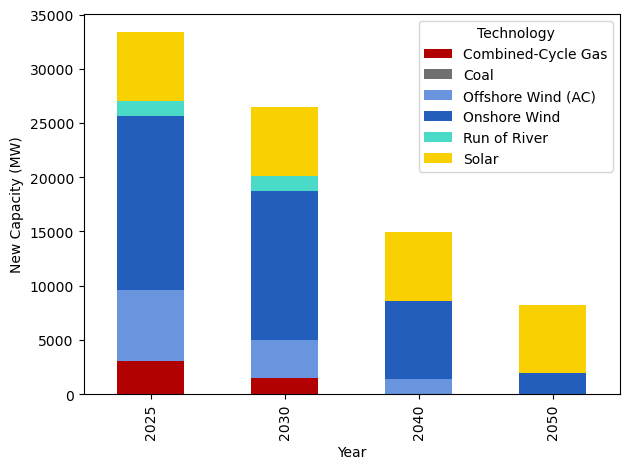

In [20]:
analytics.plot_capacity_investment_by_carrier(generators, generators_save_folder)

Annual Capital Expenditure by Technology


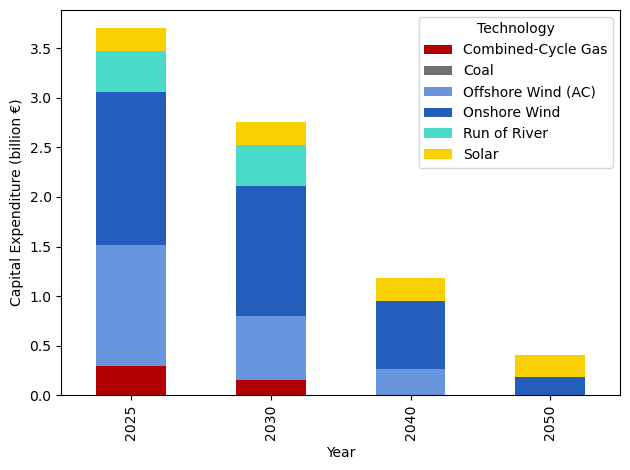

In [21]:
analytics.plot_capacity_spending_by_carrier(generators, generators_save_folder)

Growth in Total Installed Capacity


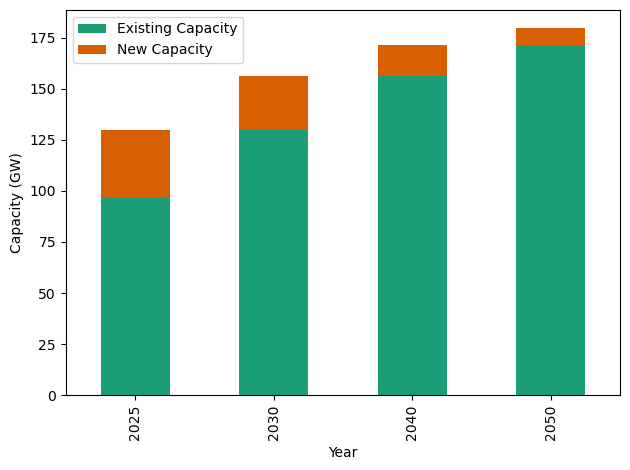

In [22]:
analytics.plot_total_capacity_growth(generators, generators_save_folder)

Extension Potential vs Actual New Capacity by Technology


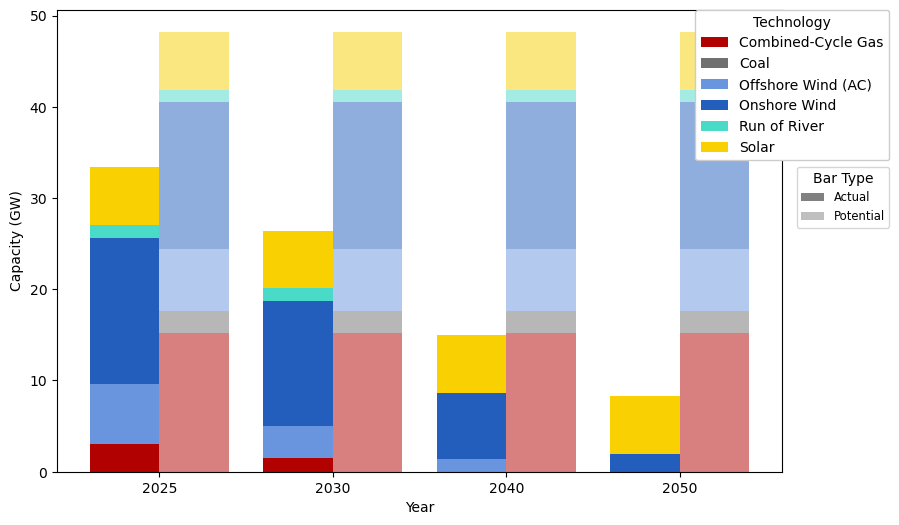

In [23]:
analytics.plot_extension_vs_potential_by_carrier(generators, generators_save_folder)

### Generators Production and Time Series Plots

In [24]:
production_by_carrier_table = analytics.create_energy_production_by_carrier_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights,
    savefolder=generators_save_table_folder,
)
production_by_carrier_table


Annual expected energy production by carrier (scenario-weighted):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar
year,,,,,,
2025,8.915814e+07,7.037113e+06,4.327656e+07,8.951069e+07,1.915410e+07,2.579712e+07
2030,7.462851e+07,4.623578e+06,4.940185e+07,1.047470e+08,2.553880e+07,3.439617e+07
2040,9.316319e+07,7.824741e+06,5.519446e+07,1.256839e+08,2.553880e+07,4.299521e+07
2050,9.926494e+07,8.937884e+06,5.579708e+07,1.326271e+08,2.553880e+07,5.159425e+07


In [25]:
annual_production_table = analytics.make_annual_production_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights=week_weights,
    savefolder=generators_save_table_folder,
)
annual_production_table

Annual expected energy production by carrier and scenario (MWh):


carrier                CCGT          coal    offwind-ac        onwind  \
year scenario                                                           
2025 NT        8.915814e+07  7.037113e+06  4.327656e+07  8.951069e+07   
2030 NT        7.462851e+07  4.623578e+06  4.940185e+07  1.047470e+08   
2040 DE        3.456715e+07  3.140282e+06  1.875316e+07  4.298951e+07   
     GA        2.593650e+07  1.833273e+06  1.790542e+07  4.019538e+07   
     NT        3.265954e+07  2.851186e+06  1.853588e+07  4.249904e+07   
2050 DE        5.684612e+07  5.671296e+06  2.854925e+07  6.848731e+07   
     GA        4.241883e+07  3.266587e+06  2.724784e+07  6.413983e+07   

carrier                 ror         solar         Total  
year scenario                                            
2025 NT        1.915410e+07  2.579712e+07  2.739337e+08  
2030 NT        2.553880e+07  3.439617e+07  2.933360e+08  
2040 DE        8.512935e+06  1.433174e+07  1.222948e+08  
     GA        8.512935e+06  1.433174e+07  1.087152e+08  
     NT        8.512935e+06  1.433174e+07  1.193903e+08  
2050 DE        1.276940e+07  2.579712e+07  1.981205e+08  
     GA        1.276940e+07  2.579712e+07  1.756396e+08

In [26]:
annual_cost_table = analytics.make_weighted_annual_production_cost_by_year_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights,
    carbon_price=CO2_price,
    savefolder=generators_save_table_folder,
)
annual_cost_table

Annual scenario-weighted production cost (incl. CO₂) by technology (EUR):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar,Total
year,,,,,,,
2025,4.895165e+09,3.898347e+08,649148.376031,1.342660e+06,0.0,257971.242230,5.287249e+09
2030,4.097813e+09,2.561322e+08,741027.759582,1.571206e+06,0.0,343961.656306,4.356602e+09
2040,5.122327e+09,4.334670e+08,827916.875635,1.885259e+06,0.0,429952.070383,5.558937e+09
2050,5.466187e+09,4.951317e+08,836956.242350,1.989407e+06,0.0,515942.484459,5.964661e+09


In [27]:
weighted_annual_production_by_year = analytics.make_weighted_annual_production_by_year(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights=week_weights,
    savefolder=generators_save_table_folder,
)
weighted_annual_production_by_year

Annual scenario-weighted energy production by carrier (MWh):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar,Total
year,,,,,,,
2025,8.915814e+07,7.037113e+06,4.327656e+07,8.951069e+07,1.915410e+07,2.579712e+07,2.739337e+08
2030,7.462851e+07,4.623578e+06,4.940185e+07,1.047470e+08,2.553880e+07,3.439617e+07,2.933360e+08
2040,9.316319e+07,7.824741e+06,5.519446e+07,1.256839e+08,2.553880e+07,4.299521e+07,3.504003e+08
2050,9.926494e+07,8.937884e+06,5.579708e+07,1.326271e+08,2.553880e+07,5.159425e+07,3.737601e+08


Evolution of Annual Energy Production by Technology (averaged across scenarios)


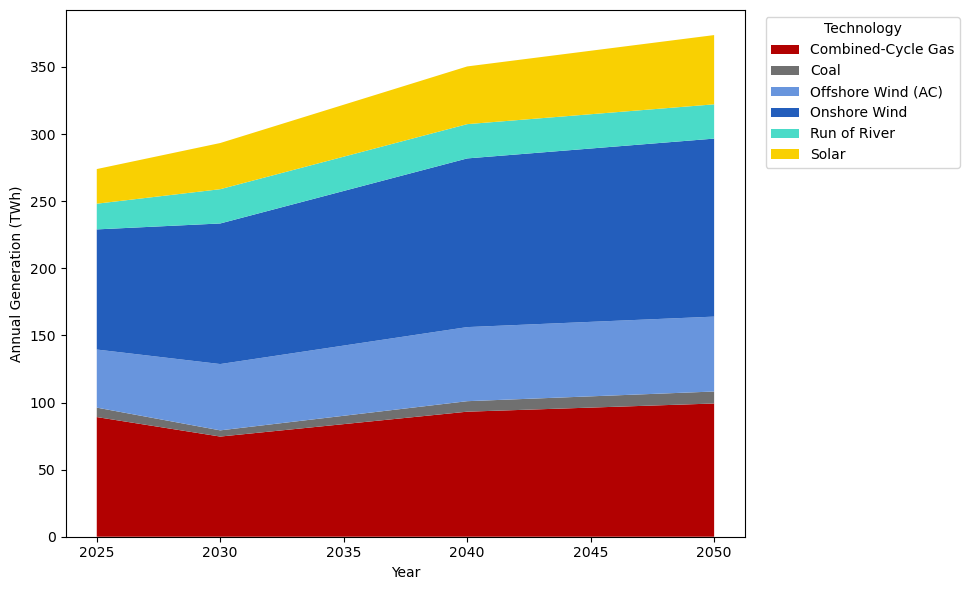

Evolution of Annual Energy Production by Technology (averaged across scenarios)


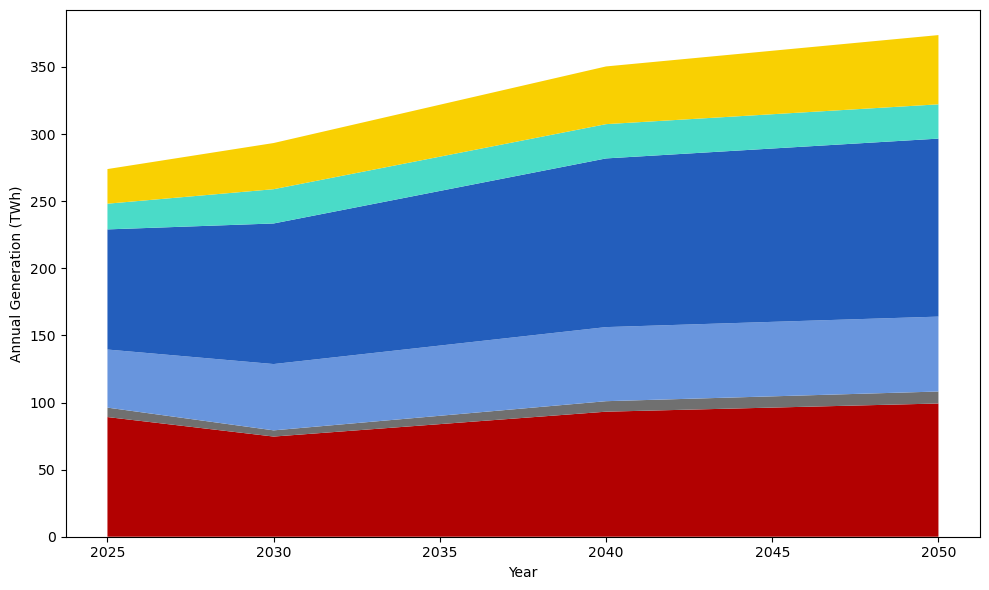

In [28]:
analytics.plot_weighted_production_evolution(
    weighted_annual_production_by_year, generators, savefolder=generators_save_folder
)

analytics.plot_weighted_production_evolution_no_legend(
    weighted_annual_production_by_year, generators, savefolder=generators_save_folder
)

Evolution of Annual Production Cost including CO₂ Emissions by Technology


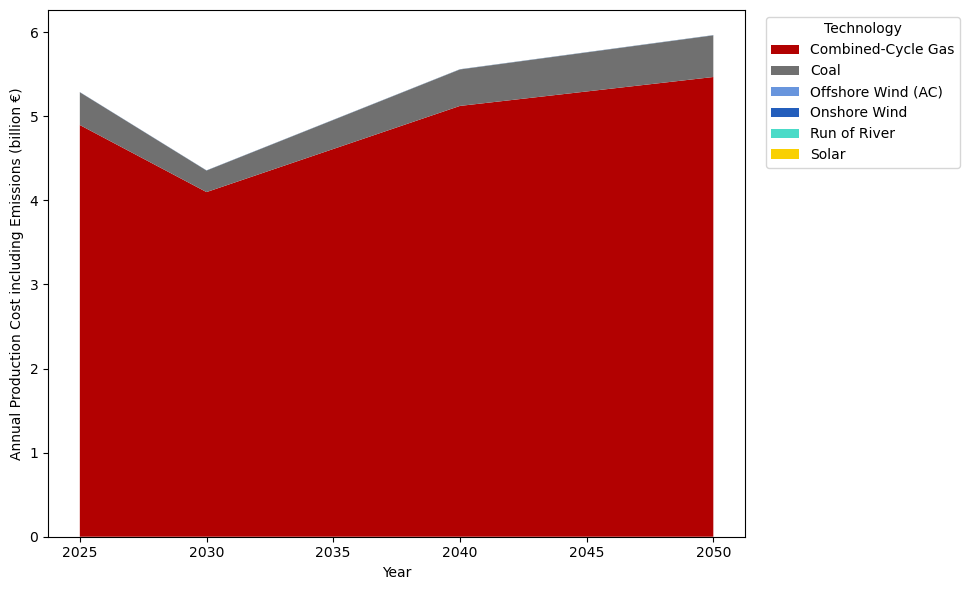

In [29]:
analytics.plot_weighted_production_cost_evolution(
    annual_cost_table, generators, savefolder=generators_save_folder
)

In [30]:
yearly_system_cost_table = analytics.make_yearly_system_costs_table(
    generation, generators, week_weights, CO2_price, generators_save_table_folder
)
yearly_system_cost_table

Yearly system metrics by year and scenario:


production  co2_emission  co2_emission_cost  production_cost  \
year scenario                                                                   
2025 NT        2.739337e+08  2.022425e+07       1.617940e+09     3.669310e+09   
2030 NT        2.933360e+08  1.649772e+07       1.319817e+09     3.036784e+09   
2040 DE        3.668843e+08  2.394338e+07       1.915470e+09     4.314016e+09   
     GA        3.261457e+08  1.743184e+07       1.394547e+09     3.188365e+09   
     NT        3.581710e+08  2.250394e+07       1.800315e+09     4.064099e+09   
2050 DE        3.962410e+08  2.659493e+07       2.127594e+09     4.772942e+09   
     GA        3.512792e+08  1.918881e+07       1.535105e+09     3.493681e+09   

               production_cost_with_emission  
year scenario                                 
2025 NT                         5.287249e+09  
2030 NT                         4.356602e+09  
2040 DE                         6.229486e+09  
     GA                         4.582912e+09  
     NT                         5.864414e+09  
2050 DE                         6.900536e+09  
     GA                         5.028786e+09

CO₂ Emissions by Year and Scenario


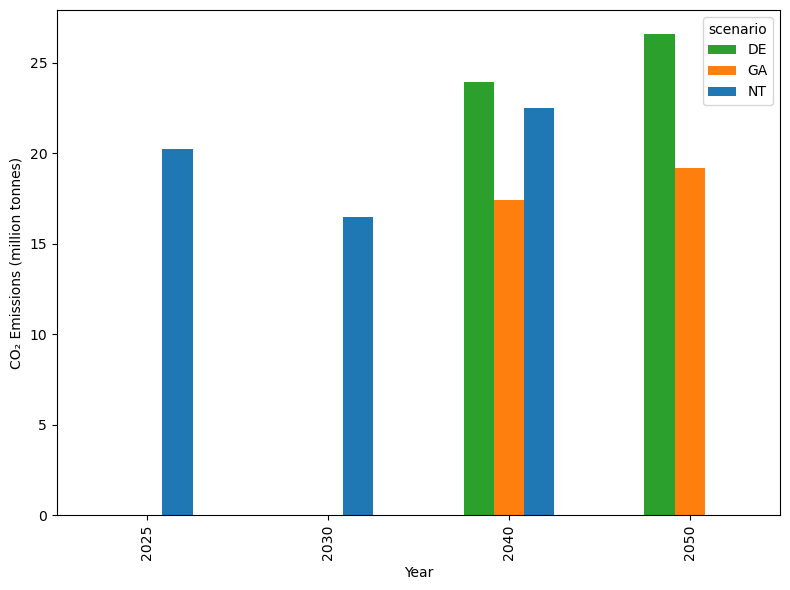

CO₂ Emissions by Year, Scenario, and Average


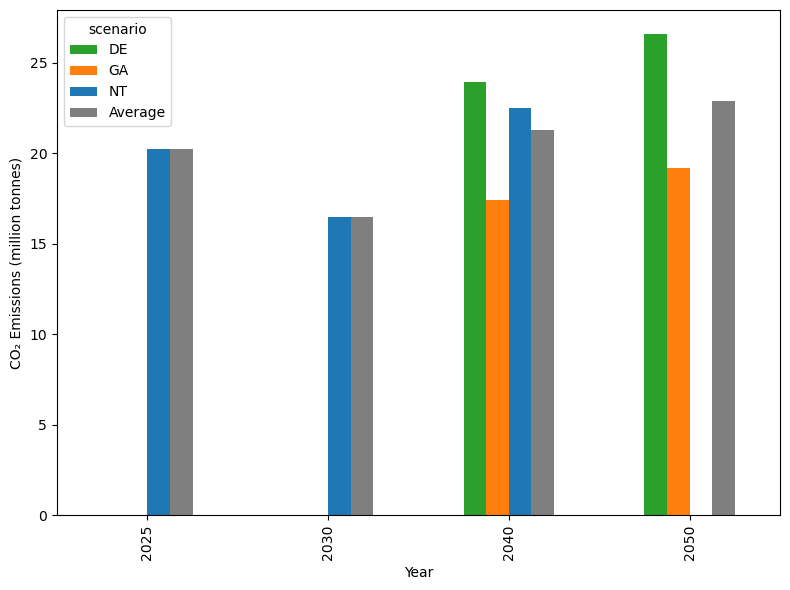

Annual Production by Year, Scenario, and Average


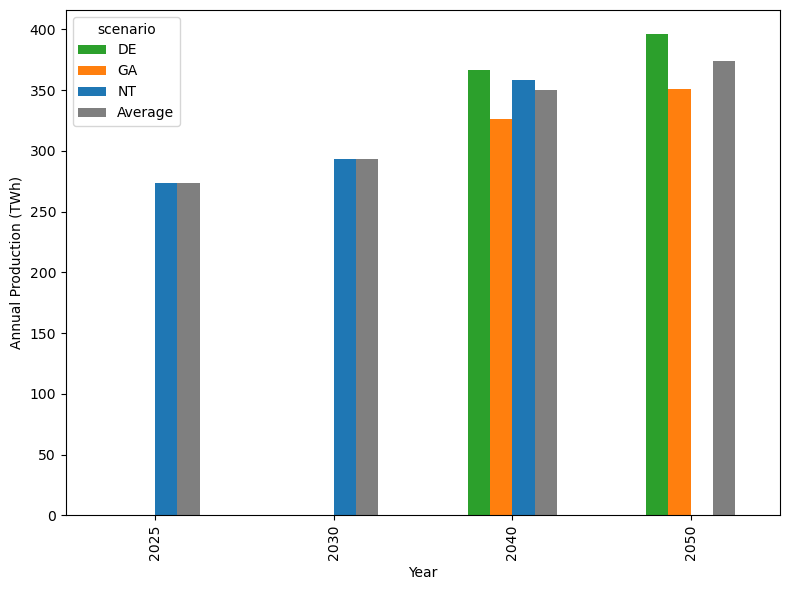

Production Cost by Year, Scenario, and Average


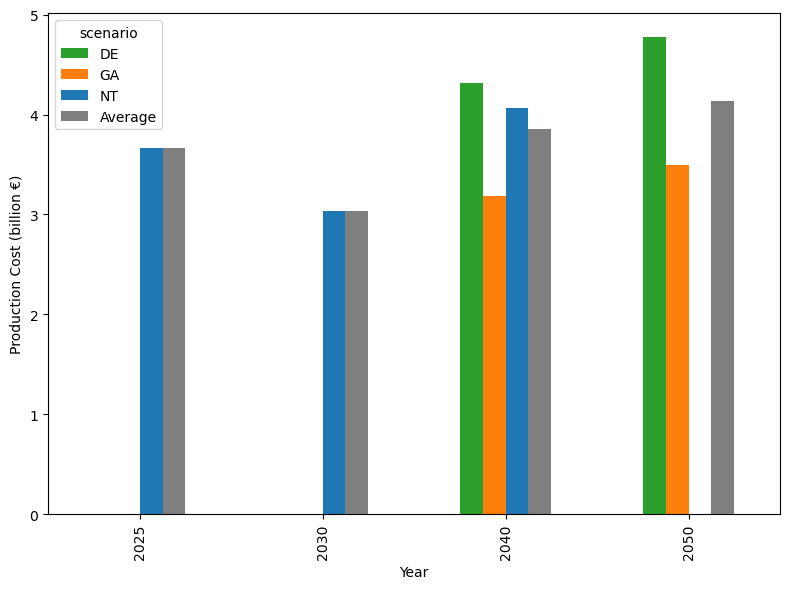

Production Cost w/ Emissions by Year, Scenario, and Average


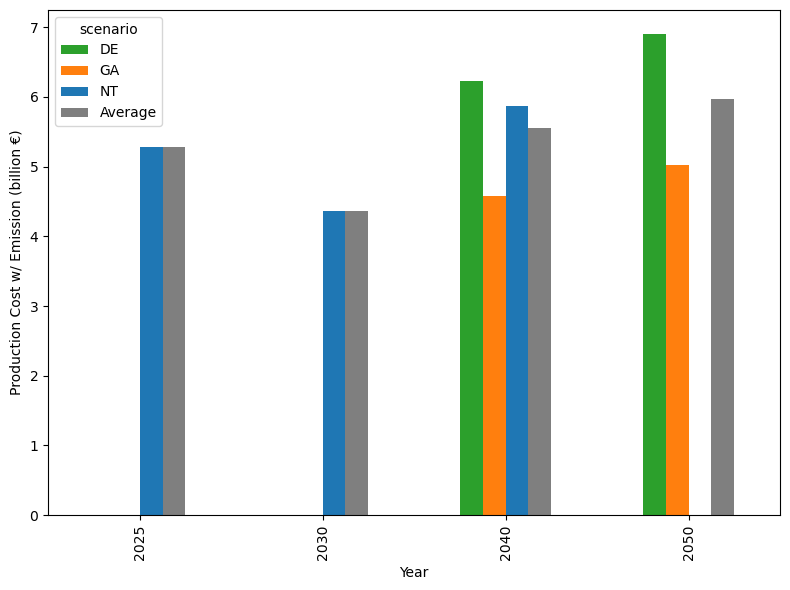

In [31]:
analytics.plot_co2_emissions_by_scenario(
    yearly_system_cost_table, savefolder=generators_save_folder
)
analytics.plot_co2_emissions_by_scenario_avg(
    yearly_system_cost_table, generators_save_folder
)
analytics.plot_production_by_scenario(yearly_system_cost_table, generators_save_folder)
analytics.plot_production_cost_by_scenario(
    yearly_system_cost_table, generators_save_folder
)
analytics.plot_production_cost_with_emission_by_scenario(
    yearly_system_cost_table, generators_save_folder
)

In [32]:
# if figures_folder:
#     generation_curves_folder = os.path.join(figures_folder, "generation_curves")
#     os.makedirs(generation_curves_folder, exist_ok=True)
# else:
#     generation_curves_folder = None

# years = [int(y) for y in scenarios.keys()]
# weeks = [int(w) for w in week_weights.keys()]
# carriers = generators.reset_index()["carrier"].unique()

# for year in years:
#     for scen in scenarios[str(year)]:
#         for week in weeks:
#             for carrier in carriers:
#                 analytics.plot_fraction_of_max_generation_by_carrier(
#                     generation,
#                     capacity_factors,
#                     generators,
#                     year,
#                     week,
#                     scen,
#                     carrier,
#                     savefolder=generation_curves_folder,  # or None if you don’t want to save
#                 )

In [33]:
# # loop over combinations
# years = [int(y) for y in scenarios.keys()]
# weeks = [int(w) for w in week_weights.keys()]
# for year in years:
#     for scen in scenarios[str(year)]:
#         for week in weeks:
#             analytics.plot_utilization_time_series_by_carrier(
#                 generation,
#                 capacity_factors,
#                 generators,
#                 year,
#                 week,
#                 scen,
#                 savefolder=tables_folder,
#             )

In [34]:
generators

,,bus,carrier,p_nom,marginal_cost,capital_cost,co2_emissions,color,nice_name,extendable,extension_potential,new_capacity,cum_new_capacity,cum_extension_potential,total_capacity
year,generator,,,,,,,,,,,,,,
2025,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,1712.650000,3425.300000
2030,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,98977.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,3425.300000,3425.300000
2040,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,98927.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,5137.950000,3425.300000
2050,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,98877.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,6850.600000,3425.300000
2025,ES1 0 coal,ES1 0,coal,1068.524933,28.196970,349976.553630,0.34,#707070,Coal,True,534.262466,0.000000,0.000000,534.262466,1068.524933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2050,PT1 1 ror,PT1 1,ror,269.600000,0.000000,298990.224929,0.00,#4adbc8,Run of River,True,134.800000,0.000000,269.600000,539.200000,539.200000
2025,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35602.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,324.036799,324.036799,972.110398
2030,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35552.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,648.073599,648.073599,1296.147198


Annual Utilization Factor by Year, Scenario, and Carrier


c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:2481: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  actual_car = actual.groupby(gen2car, axis=1).sum()  # (year,scenario)×carrier
c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:2482: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  potential_car = potential.groupby(gen2car, axis=1).sum()  # year×carrier


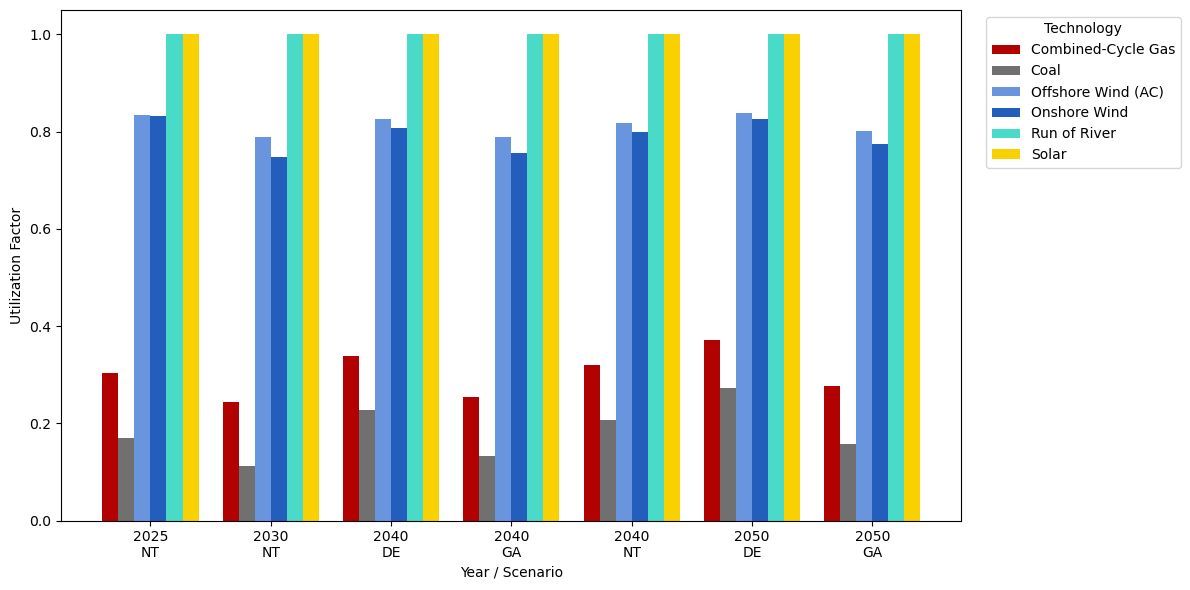

In [35]:
analytics.plot_utilization_hierarchy(
    generation,
    capacity_factors,
    generators,
    week_weights,
    scenarios,
    savefolder=generators_save_folder,
)

In [36]:
summary_table = analytics.make_system_summary_table(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    savefolder=tables_folder,
)

In [37]:
summary_table

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout,total_production,total_co2_emissions,total_co2_emission_cost,total_production_cost,total_production_cost_with_emission,total_cost
year,,,,,,,,,,,
2025,48228.204285,33398.568524,51,38,3.700588e+09,2.739337e+08,2.022425e+07,1.617940e+09,3.669310e+09,5.287249e+09,8.987837e+09
2030,48228.204285,26440.225829,51,30,2.752935e+09,2.933360e+08,1.649772e+07,1.319817e+09,3.036784e+09,4.356602e+09,7.109537e+09
2040,48228.204285,14971.160576,51,18,1.178740e+09,3.504003e+08,2.129305e+07,1.703444e+09,3.855493e+09,5.558937e+09,6.737677e+09
2050,48228.204285,8270.018234,51,12,4.091070e+08,3.737601e+08,2.289187e+07,1.831350e+09,4.133312e+09,5.964661e+09,6.373768e+09


In [38]:
summary_by_carrier_table = analytics.make_system_summary_table_by_carrier(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    tables_folder,
)
summary_by_carrier_table

potential_capacity  new_capacity  number_possible_buildouts  \
year carrier                                                                   
2025 CCGT              15225.166000   3020.731848                         11   
     coal               2369.696741      0.000000                          5   
     offwind-ac         6867.326111   6611.821243                          9   
     onwind            16019.751672  16019.751672                         11   
     ror                1392.754124   1392.754124                          4   
     solar              6353.509637   6353.509637                         11   
2030 CCGT              15225.166000   1502.000000                         11   
     coal               2369.696741      0.000000                          5   
     offwind-ac         6867.326111   3510.341607                          9   
     onwind            16019.751672  13681.620462                         11   
     ror                1392.754124   1392.754124                          4   
     solar              6353.509637   6353.509637                         11   
2040 CCGT              15225.166000      0.000000                         11   
     coal               2369.696741      0.000000                          5   
     offwind-ac         6867.326111   1437.551690                          9   
     onwind            16019.751672   7180.099250                         11   
     ror                1392.754124      0.000000                          4   
     solar              6353.509637   6353.509637                         11   
2050 CCGT              15225.166000      0.000000                         11   
     coal               2369.696741      0.000000                          5   
     offwind-ac         6867.326111      0.000000                          9   
     onwind            16019.751672   1916.508598                         11   
     ror                1392.754124      0.000000                          4   
     solar              6353.509637   6353.509637                         11   

                 number_actual_buildouts  cost_of_buildout  total_production  \
year carrier                                                                   
2025 CCGT                              4      2.991362e+08      8.915814e+07   
     coal                              0      0.000000e+00      7.037113e+06   
     offwind-ac                        8      1.219353e+09      4.327656e+07   
     onwind                           11      1.539272e+09      8.951069e+07   
     ror                               4      4.166288e+08      1.915410e+07   
     solar                            11      2.261981e+08      2.579712e+07   
2030 CCGT                              1      1.486645e+08      7.462851e+07   
     coal                              0      0.000000e+00      4.623578e+06   
     offwind-ac                        5      6.479042e+08      4.940185e+07   
     onwind                            9      1.313927e+09      1.047470e+08   
     ror                               4      4.165591e+08      2.553880e+07   
     solar                            11      2.258804e+08      3.439617e+07   
2040 CCGT                              0      0.000000e+00      9.316319e+07   
     coal                              0      0.000000e+00      7.824741e+06   
     offwind-ac                        2      2.639889e+08      5.519446e+07   
     onwind                            5      6.891882e+08      1.256839e+08   
     ror                               0      0.000000e+00      2.553880e+07   
     solar                            11      2.255628e+08      4.299521e+07   
2050 CCGT                              0      0.000000e+00      9.926494e+07   
     coal                              0      0.000000e+00      8.937884e+06   
     offwind-ac                        0      0.000000e+00      5.579708e+07   
     onwind                            1      1.838620e+08      1.326271e+08   
     ror        

## Transmission Lines

In [39]:
# Preprocessing
if "extended_by" in branches.columns:
    branches.drop(columns=["extended_by"], inplace=True)
if "branch" in branch_capacity.index.names:
    branch_capacity = branch_capacity.rename_axis(index={"branch": "line"})
if "branch" in power_flow.index.names:
    power_flow = power_flow.rename_axis(index={"branch": "line"})
branches["extension_potential"] = p_max_new_branch

In [40]:
if SAVE_FIGURES:
    branches_save_folder = os.path.join(figures_folder, "branches")
    if not os.path.exists(branches_save_folder):
        os.makedirs(branches_save_folder)
else:
    branches_save_folder = None
if SAVE_TABLES:
    branches_save_table_folder = os.path.join(tables_folder, "branches")
    if not os.path.exists(branches_save_table_folder):
        os.makedirs(branches_save_table_folder)
else:
    branches_save_table_folder = None

In [41]:
branches = analytics.extend_branches_table(branches, branch_capacity)

In [42]:
branches["capital_cost"]

year  line
2025  88      23102.962586
2030  88      23052.962586
2040  88      23002.962586
2050  88      22952.962586
2025  89      11729.199350
                  ...     
2050  107     21911.025373
2025  219     14480.882016
2030  219     14430.882016
2040  219     14380.882016
2050  219     14330.882016
Name: capital_cost, Length: 76, dtype: float64

Annual New Branch Capacity Additions


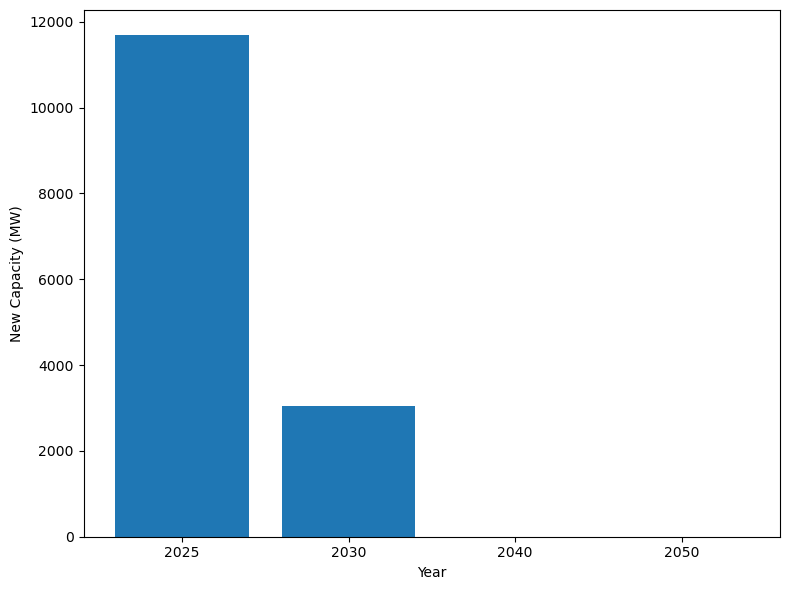

In [43]:
analytics.plot_branch_new_capacity(branches, savefolder=branches_save_folder)

In [44]:
branch_buildout_summary = analytics.make_branch_buildout_summary(
    branches, savefolder=branches_save_table_folder
)


branch_buildout_summary

Branch buildout summary by year:


,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout
year,,,,,
2025,95000,11689.704453,19,3,2.009912e+08
2030,95000,3043.754800,19,1,3.981689e+07
2040,95000,0.000000,19,0,0.000000e+00
2050,95000,0.000000,19,0,0.000000e+00


In [45]:
branch_flow_table_per_line = analytics.make_branch_flow_metrics(
    power_flow, branches, week_weights, savefolder=branches_save_table_folder
)
branch_flow_table_per_line

utilization_rate  congestion_rate
line scenario year                                   
88   DE       2040          0.972949         0.852679
              2050          0.971678         0.830357
     GA       2040          0.984721         0.912202
              2050          0.981598         0.895833
     NT       2025          0.981461         0.912202
...                              ...              ...
219  GA       2040          0.808436         0.247024
              2050          0.801837         0.276786
     NT       2025          0.726641         0.044643
              2030          0.825830         0.275298
              2040          0.812119         0.263393

[133 rows x 2 columns]

In [46]:
branch_flow_summary = analytics.make_aggregate_branch_flow_summary(
    power_flow, branches, week_weights, savefolder=branches_save_table_folder
)
branch_flow_summary

utilization_rate  congestion_rate
year scenario                                   
2025 NT                0.636646         0.515742
2030 NT                0.661907         0.512531
2040 DE                0.663380         0.520050
     GA                0.661947         0.512453
     NT                0.662985         0.517466
2050 DE                0.663550         0.523575
     GA                0.661159         0.518875

Transmission line investments in 2025:


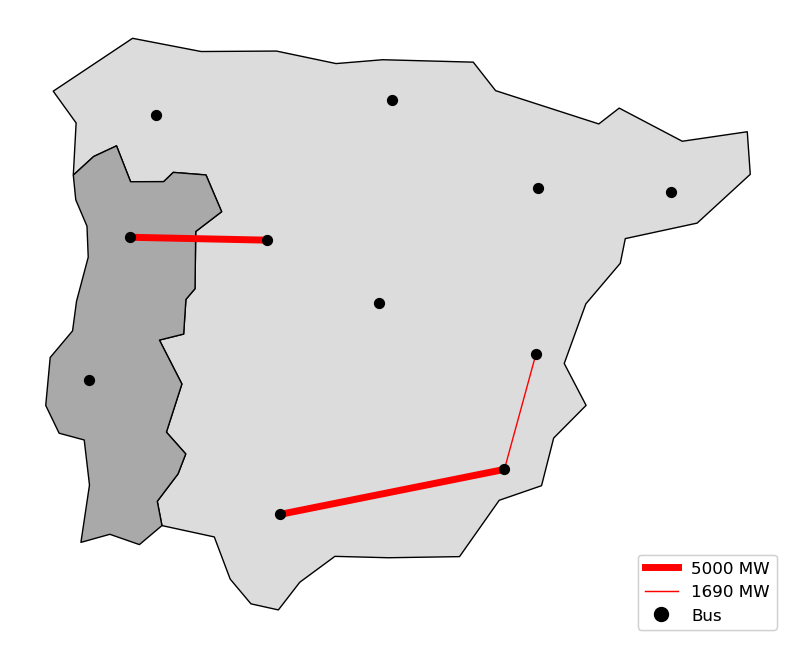

Plotting grid with new branches in year 2025
Transmission line investments in 2030:


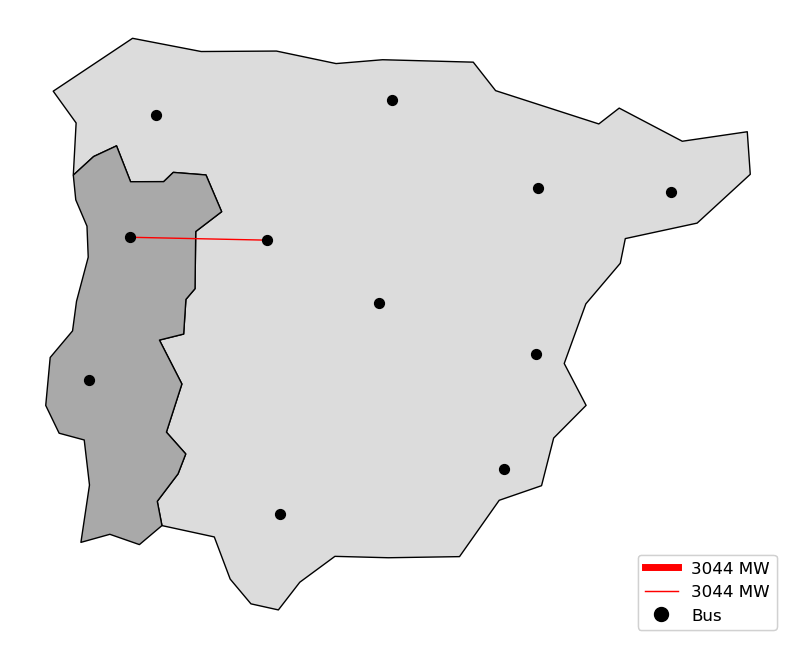

Plotting grid with new branches in year 2030


In [47]:
analytics.plot_new_branches_for_years_with_investments(
    branches, branch_capacity, nodes, savefolder=branches_save_folder
)

## Batteries

In [48]:
if SAVE_FIGURES:
    batteries_save_folder = os.path.join(figures_folder, "batteries")
    if not os.path.exists(batteries_save_folder):
        os.makedirs(batteries_save_folder)
else:
    batteries_save_folder = None
if SAVE_TABLES:
    batteries_save_table_folder = os.path.join(tables_folder, "batteries")
    if not os.path.exists(batteries_save_table_folder):
        os.makedirs(batteries_save_table_folder)
else:
    batteries_save_table_folder = None

Annual Battery Capacity Investments


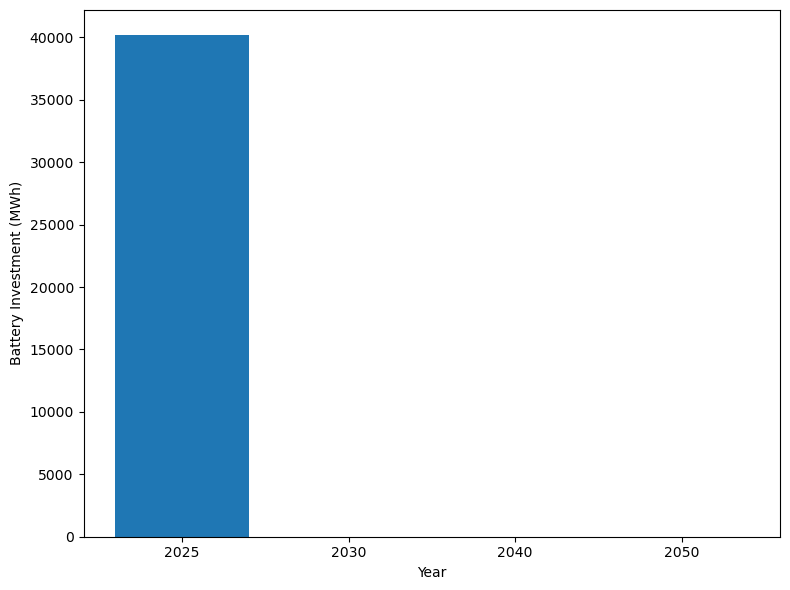

Annual Battery Investment Cost (million €)


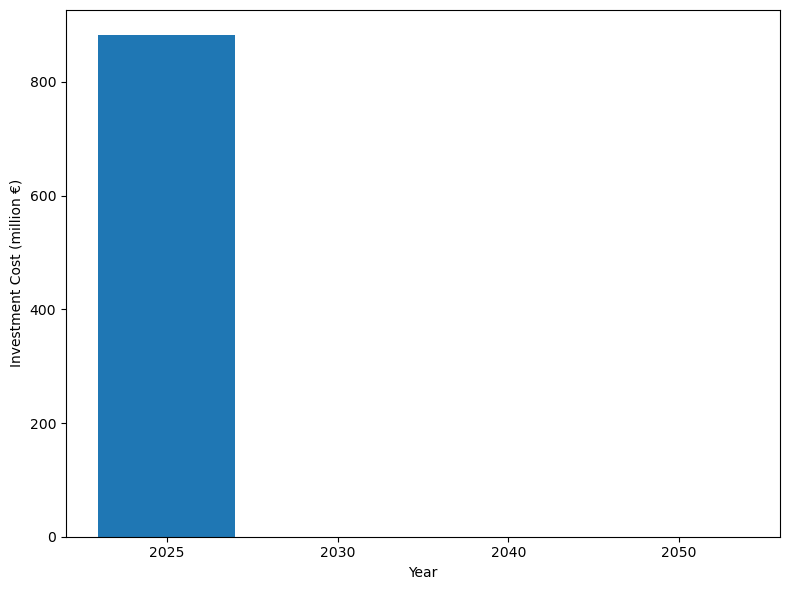

Number of 320 MWh Cycles by Year, Scenario, and Average


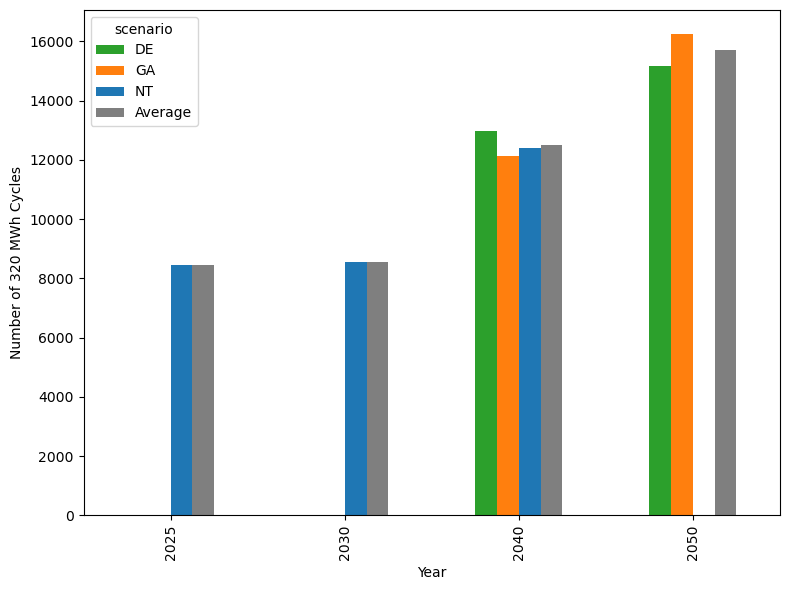

In [49]:
if len(batteries) > 0:
    batteries = analytics.extend_batteries_table(batteries.copy(), battery_capacity)
    analytics.plot_battery_investment_by_year(
        batteries, savefolder=batteries_save_folder
    )
    analytics.plot_battery_investment_cost_by_year(
        batteries, savefolder=batteries_save_folder
    )
    battery_summary = analytics.make_battery_system_summary(
        batteries,
        battery_discharging,
        week_weights,
        scenarios,
        scenario_probabilities,
        batteries_save_table_folder,
    )
    analytics.plot_cycles_per_scenario_with_average(
        battery_discharging,
        week_weights,
        reference_cycle_mwh=400 * (0.8),
        savefolder=batteries_save_folder,
    )
    battery_summary

In [50]:
battery_summary

,num_buildout,capacity,investment_cost,cycles_per_year
year,,,,
2025,3,40177.863459,8.822627e+08,67.419355
2030,0,40177.863459,0.000000e+00,68.140667
2040,0,40177.863459,0.000000e+00,99.575961
2050,0,40177.863459,0.000000e+00,125.173379


Annual Curtailment by Year and Scenario


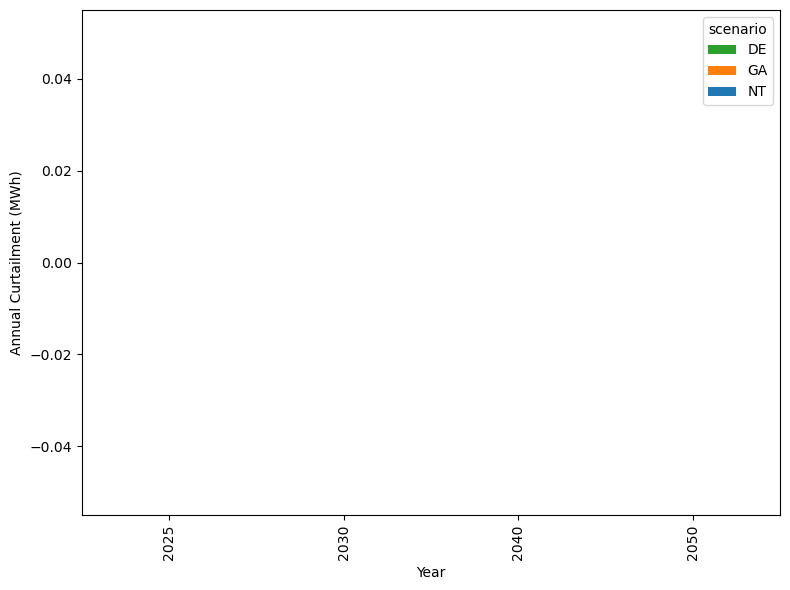

Annual Load Shedding by Year and Scenario


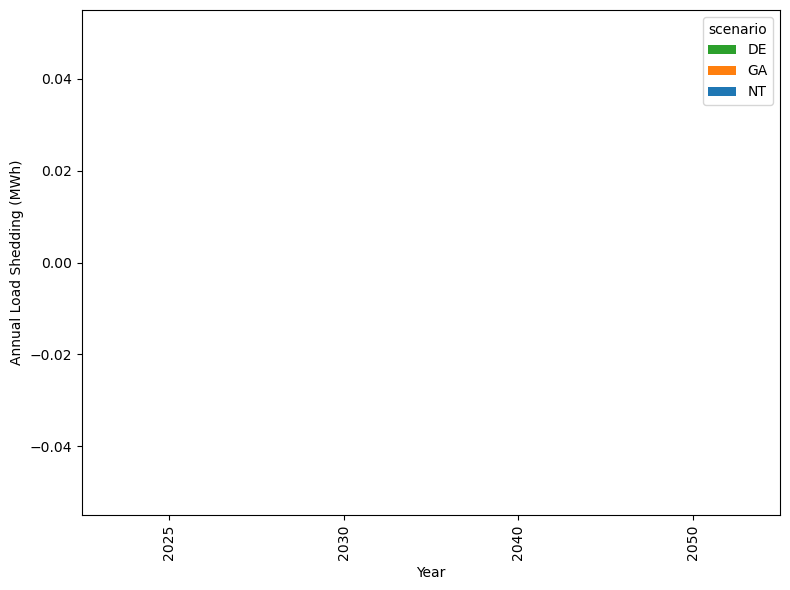

In [51]:
analytics.plot_curtailment_by_scenario(
    curtailment, week_weights, savefolder=figures_folder
)


analytics.plot_load_shedding_by_scenario(
    load_shedding, week_weights, savefolder=figures_folder
)

In [52]:
curtailment_and_load_shedding_table = (
    analytics.make_curtailment_load_shedding_cost_table(
        curtailment, load_shedding, week_weights, CC, VOLL, savefolder=tables_folder
    )
)
curtailment_and_load_shedding_table

load_shedding  curtailment  load_shedding_cost  \
year scenario                                                   
2025 NT                  0.0          0.0                 0.0   
2030 NT                  0.0          0.0                 0.0   
2040 DE                  0.0          0.0                 0.0   
     GA                  0.0          0.0                 0.0   
     NT                  0.0          0.0                 0.0   
2050 DE                  0.0          0.0                 0.0   
     GA                  0.0          0.0                 0.0   

               curtailment_cost  
year scenario                    
2025 NT                     0.0  
2030 NT                     0.0  
2040 DE                     0.0  
     GA                     0.0  
     NT                     0.0  
2050 DE                     0.0  
     GA                     0.0

## Macro analysis

In [53]:
if SAVE_FIGURES:
    macro_save_folder = os.path.join(figures_folder, "macro")
    if not os.path.exists(macro_save_folder):
        os.makedirs(macro_save_folder)
else:
    macro_save_folder = None
if SAVE_TABLES:
    macro_save_table_folder = os.path.join(tables_folder, "macro")
    if not os.path.exists(macro_save_table_folder):
        os.makedirs(macro_save_table_folder)
else:
    macro_save_table_folder = None

In [54]:
system_summary = analytics.make_system_summary_table(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    savefolder=macro_save_folder,
)

In [55]:
system_summary

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout,total_production,total_co2_emissions,total_co2_emission_cost,total_production_cost,total_production_cost_with_emission,total_cost
year,,,,,,,,,,,
2025,48228.204285,33398.568524,51,38,3.700588e+09,2.739337e+08,2.022425e+07,1.617940e+09,3.669310e+09,5.287249e+09,8.987837e+09
2030,48228.204285,26440.225829,51,30,2.752935e+09,2.933360e+08,1.649772e+07,1.319817e+09,3.036784e+09,4.356602e+09,7.109537e+09
2040,48228.204285,14971.160576,51,18,1.178740e+09,3.504003e+08,2.129305e+07,1.703444e+09,3.855493e+09,5.558937e+09,6.737677e+09
2050,48228.204285,8270.018234,51,12,4.091070e+08,3.737601e+08,2.289187e+07,1.831350e+09,4.133312e+09,5.964661e+09,6.373768e+09


In [56]:
if len(batteries) > 0:
    battery_summary = analytics.make_battery_system_summary(
        batteries,
        battery_discharging,
        week_weights,
        scenarios,
        scenario_probabilities,
        savefolder=tables_folder,
    )
else:
    # Dummy columns
    columns = ["num_buildout", "capacity", "investment_cost", "cycles_per_year"]

    # Create the DataFrame with NaNs
    empty_df = pd.DataFrame(index=years, columns=columns)
    empty_df.index.name = "year"
    battery_summary = empty_df

In [57]:
battery_summary

,num_buildout,capacity,investment_cost,cycles_per_year
year,,,,
2025,3,40177.863459,8.822627e+08,67.419355
2030,0,40177.863459,0.000000e+00,68.140667
2040,0,40177.863459,0.000000e+00,99.575961
2050,0,40177.863459,0.000000e+00,125.173379


In [58]:
branch_summary = analytics.make_branch_buildout_summary(branches, tables_folder)
yearly_system_cost_table = analytics.make_yearly_system_costs_table(
    generation, generators, week_weights, CO2_price, savefolder=tables_folder
)
curtailment_and_load_shedding_table = (
    analytics.make_curtailment_load_shedding_cost_table(
        curtailment, load_shedding, week_weights, CC, VOLL, savefolder=tables_folder
    )
)

Branch buildout summary by year:
Yearly system metrics by year and scenario:


In [59]:
branch_summary

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout
year,,,,,
2025,95000,11689.704453,19,3,2.009912e+08
2030,95000,3043.754800,19,1,3.981689e+07
2040,95000,0.000000,19,0,0.000000e+00
2050,95000,0.000000,19,0,0.000000e+00


In [60]:
yearly_system_cost_table

production  co2_emission  co2_emission_cost  production_cost  \
year scenario                                                                   
2025 NT        2.739337e+08  2.022425e+07       1.617940e+09     3.669310e+09   
2030 NT        2.933360e+08  1.649772e+07       1.319817e+09     3.036784e+09   
2040 DE        3.668843e+08  2.394338e+07       1.915470e+09     4.314016e+09   
     GA        3.261457e+08  1.743184e+07       1.394547e+09     3.188365e+09   
     NT        3.581710e+08  2.250394e+07       1.800315e+09     4.064099e+09   
2050 DE        3.962410e+08  2.659493e+07       2.127594e+09     4.772942e+09   
     GA        3.512792e+08  1.918881e+07       1.535105e+09     3.493681e+09   

               production_cost_with_emission  
year scenario                                 
2025 NT                         5.287249e+09  
2030 NT                         4.356602e+09  
2040 DE                         6.229486e+09  
     GA                         4.582912e+09  
     NT                         5.864414e+09  
2050 DE                         6.900536e+09  
     GA                         5.028786e+09

In [61]:
curtailment_and_load_shedding_table

load_shedding  curtailment  load_shedding_cost  \
year scenario                                                   
2025 NT                  0.0          0.0                 0.0   
2030 NT                  0.0          0.0                 0.0   
2040 DE                  0.0          0.0                 0.0   
     GA                  0.0          0.0                 0.0   
     NT                  0.0          0.0                 0.0   
2050 DE                  0.0          0.0                 0.0   
     GA                  0.0          0.0                 0.0   

               curtailment_cost  
year scenario                    
2025 NT                     0.0  
2030 NT                     0.0  
2040 DE                     0.0  
     GA                     0.0  
     NT                     0.0  
2050 DE                     0.0  
     GA                     0.0

Annual System Costs (average across scenarios)


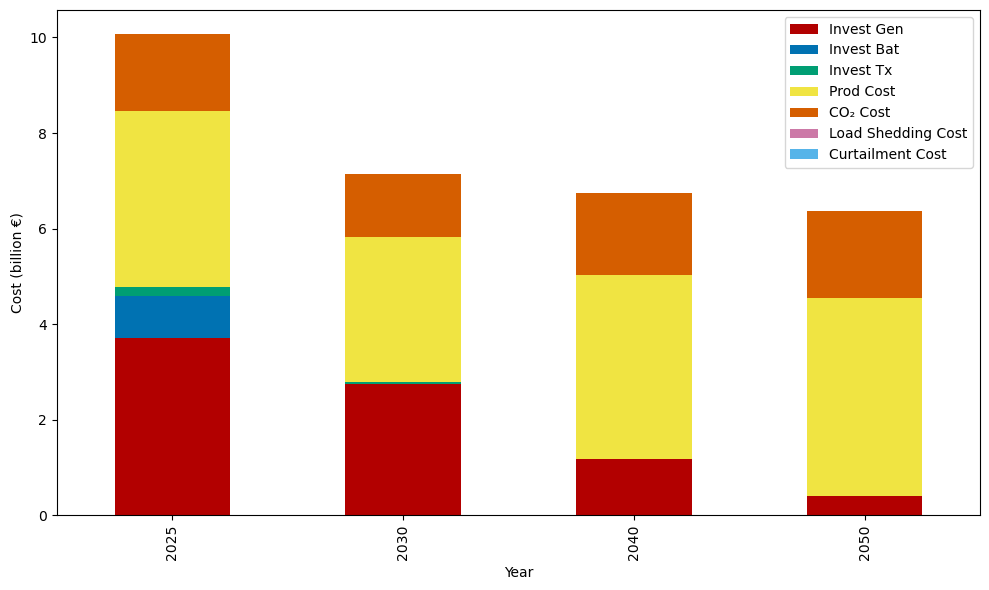

Annual System Costs by Scenario


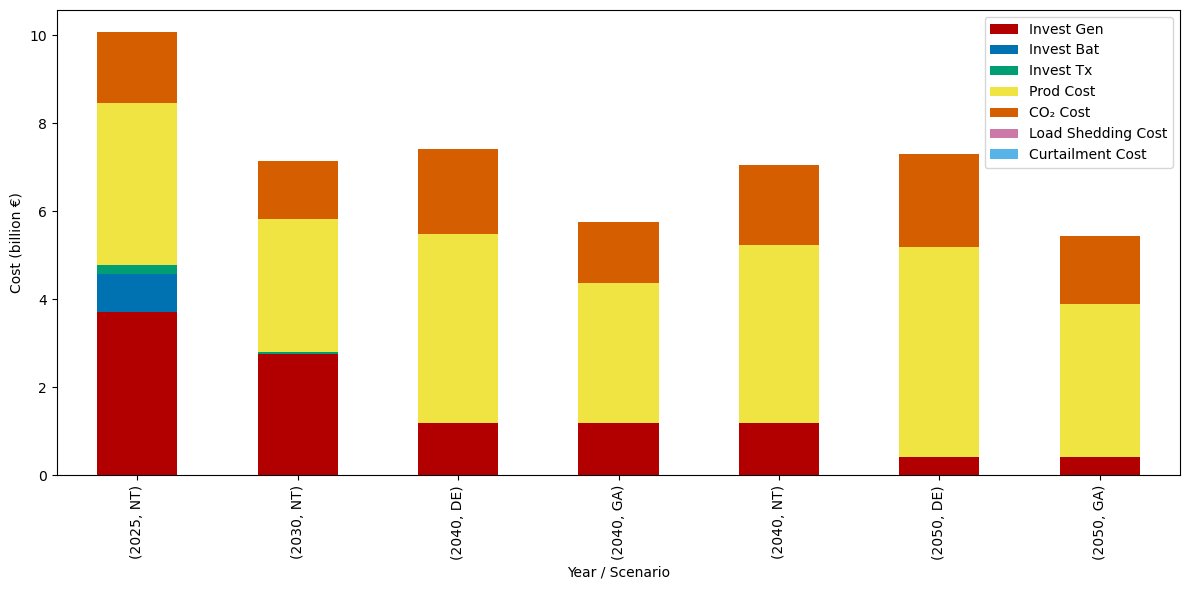

In [62]:
analytics.plot_yearly_costs_stacked_avg(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    savefolder=macro_save_folder,
)
analytics.plot_yearly_costs_stacked_by_scenario(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    savefolder=macro_save_folder,
)

In [63]:
total_system_cost = analytics.compute_total_system_cost(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    scenarios,
    scenario_probabilities,
    savefolder=macro_save_table_folder,
)
total_system_cost

Total system cost by year:


,AIC,expected_OC,total_cost
year,,,
2025,4.783842e+09,5.287249e+09,1.007109e+10
2030,2.792752e+09,4.356602e+09,7.149354e+09
2040,1.178740e+09,5.558937e+09,6.737677e+09
2050,4.091070e+08,5.964661e+09,6.373768e+09


In [64]:
assert (
    abs(total_system_cost["total_cost"].sum() - model_info["Objective Value"][0]) < 1000
), f"Mismatch in total system cost: {total_system_cost['total_cost'].sum():,.0f} vs {model_info['Objective Value'][0]:,.0f}"

In [65]:
mega_table = analytics.make_mega_cost_table(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    scenarios,
    scenario_probabilities,
    savefolder=macro_save_table_folder,
)
mega_table

Invest Gen    Invest Bat     Invest Tx  Production Cost  \
year scenario                                                              
2025 NT        3.700588e+09  8.822627e+08  2.009912e+08     3.669310e+09   
2030 NT        2.752935e+09  0.000000e+00  3.981689e+07     3.036784e+09   
2040 DE        1.178740e+09  0.000000e+00  0.000000e+00     4.314016e+09   
     GA        1.178740e+09  0.000000e+00  0.000000e+00     3.188365e+09   
     NT        1.178740e+09  0.000000e+00  0.000000e+00     4.064099e+09   
2050 DE        4.091070e+08  0.000000e+00  0.000000e+00     4.772942e+09   
     GA        4.091070e+08  0.000000e+00  0.000000e+00     3.493681e+09   
All  All       8.041370e+09  8.822627e+08  2.408081e+08     1.469490e+10   

               CO2 Emission Cost  Load Shedding Cost  Curtailment Cost  \
year scenario                                                            
2025 NT             1.617940e+09                 0.0               0.0   
2030 NT             1.319817e+09                 0.0               0.0   
2040 DE             1.915470e+09                 0.0               0.0   
     GA             1.394547e+09                 0.0               0.0   
     NT             1.800315e+09                 0.0               0.0   
2050 DE             2.127594e+09                 0.0               0.0   
     GA             1.535105e+09                 0.0               0.0   
All  All            6.472551e+09                 0.0               0.0   

               Prod+CO2 Cost   Total CapEx    Total OpEx    Total Cost  
year scenario                                                           
2025 NT         5.287249e+09  4.783842e+09  5.287249e+09  1.007109e+10  
2030 NT         4.356602e+09  2.792752e+09  4.356602e+09  7.149354e+09  
2040 DE         6.229486e+09  1.178740e+09  6.229486e+09  7.408226e+09  
     GA         4.582912e+09  1.178740e+09  4.582912e+09  5.761652e+09  
     NT         5.864414e+09  1.178740e+09  5.864414e+09  7.043154e+09  
2050 DE         6.900536e+09  4.091070e+08  6.900536e+09  7.309643e+09  
     GA         5.028786e+09  4.091070e+08  5.028786e+09  5.437893e+09  
All  All        2.116745e+10  9.164441e+09  2.116745e+10  3.033189e+10

In [66]:
generators

,,bus,carrier,p_nom,marginal_cost,capital_cost,co2_emissions,color,nice_name,extendable,extension_potential,new_capacity,cum_new_capacity,cum_extension_potential,total_capacity
year,generator,,,,,,,,,,,,,,
2025,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,1712.650000,3425.300000
2030,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,98977.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,3425.300000,3425.300000
2040,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,98927.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,5137.950000,3425.300000
2050,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,98877.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,6850.600000,3425.300000
2025,ES1 0 coal,ES1 0,coal,1068.524933,28.196970,349976.553630,0.34,#707070,Coal,True,534.262466,0.000000,0.000000,534.262466,1068.524933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2050,PT1 1 ror,PT1 1,ror,269.600000,0.000000,298990.224929,0.00,#4adbc8,Run of River,True,134.800000,0.000000,269.600000,539.200000,539.200000
2025,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35602.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,324.036799,324.036799,972.110398
2030,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35552.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,648.073599,648.073599,1296.147198


In [67]:
# End  by saving the extended generators, transmission lines, and batteries tables to and extended tables folder
if tables_folder:
    # Create the extended tables folder if it doesn't exist
    extended_tables_folder = os.path.join(tables_folder, "extended_tables")
    os.makedirs(extended_tables_folder, exist_ok=True)
    generators.to_csv(
        os.path.join(extended_tables_folder, "extended_generators.csv"), index=True
    )
    branches.to_csv(
        os.path.join(extended_tables_folder, "extended_branches.csv"), index=True
    )
    batteries.to_csv(
        os.path.join(extended_tables_folder, "extended_batteries.csv"), index=True
    )

# Dual Variables Analysis

In [68]:
for key, df in dual_variables.items():
    print(key)
    print()
    display(df.head(2))
    print("------------------------")

battery_charge_new_max_duals



dual_value
battery   scenario year week hour            
ES1 0 bat NT       2025 11   0            0.0
                             1            0.0

------------------------
battery_charge_old_duals



,,,,,,dual_value
battery,bound,scenario,year,week,hour,


------------------------
battery_discharge_new_max_duals



...

------------------------
load_shedding_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0            0.0
                         1            0.0

------------------------
power_balance_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0       0.014869
                         1       0.015050

------------------------


In [69]:
# Build a DataFrame of scenario probabilities (p_{ω,y})
prob_rows = []
for year_str, scen_list in scenarios.items():
    year = int(year_str)
    probs = scenario_probabilities[year_str]
    for scen, p in zip(scen_list, probs):
        prob_rows.append({"year": year, "scenario": scen, "p": p})
prob_df = pd.DataFrame(prob_rows).set_index(["year", "scenario"])

prob_df

p
year scenario          
2025 NT        1.000000
2030 NT        1.000000
2040 NT        0.333333
     GA        0.333333
     DE        0.333333
2050 GA        0.500000
     DE        0.500000

In [70]:
# Loop through duals and apply 1/p weighting where appropriate
for key, df in dual_variables.items():
    print(key)
    print()
    display(df.head(2))

    # Only apply to duals that vary by scenario
    if "scenario" in df.index.names:
        temp = df.reset_index().merge(prob_df, on=["year", "scenario"], how="left")
        # Compute 1/p weight
        temp["weight"] = 1.0 / temp["p"]
        # Apply weight to the dual values
        temp["dual_value"] = temp["dual_value"] * temp["weight"]

        # Reconstruct a weighted-dual Series with the original index
        weighted = temp.set_index(df.index.names)
        # Display the first two rows
        display(weighted.head(2))
        dual_variables[key] = weighted

battery_charge_new_max_duals



dual_value
battery   scenario year week hour            
ES1 0 bat NT       2025 11   0            0.0
                             1            0.0

dual_value    p  weight
battery   scenario year week hour                         
ES1 0 bat NT       2025 11   0            0.0  1.0     1.0
                             1            0.0  1.0     1.0

battery_charge_old_duals



,,,,,,dual_value
battery,bound,scenario,year,week,hour,


...

dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0            0.0
                         1            0.0

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 11   0            0.0  1.0     1.0
                         1            0.0  1.0     1.0

power_balance_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 11   0       0.014869
                         1       0.015050

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 11   0       0.014869  1.0     1.0
                         1       0.015050  1.0     1.0

In [71]:
# dual variables
battery_charge_new_max_duals = dual_variables["battery_charge_new_max_duals"]
battery_charge_old_duals = dual_variables["battery_charge_old_duals"]
battery_discharge_new_max_duals = dual_variables["battery_discharge_new_max_duals"]
battery_discharge_old_duals = dual_variables["battery_discharge_old_duals"]
branch_extension_duals = dual_variables["branch_extension_duals"]
branch_flow_old_duals_min = dual_variables["branch_flow_old_duals_min"]
branch_flow_old_duals_max = dual_variables["branch_flow_old_duals_max"]
branch_flow_new_duals_min = dual_variables["branch_flow_new_duals_min"]
branch_flow_new_duals_max = dual_variables["branch_flow_new_duals_max"]
emissions_duals = dual_variables["emissions_duals"]
gen_extension_duals = dual_variables["gen_extension_duals"]
gen_output_new_duals = dual_variables["gen_output_new_duals"]
gen_output_old_duals = dual_variables["gen_output_old_duals"]
load_shedding_duals = dual_variables["load_shedding_duals"]
power_balance_duals = dual_variables["power_balance_duals"]

### Power Balance Duals

In [72]:
node_to_city = {
    "ES1 0": "Murcia",
    "ES1 1": "Bilbao",
    "ES1 2": "Zaragoza",
    "ES1 3": "Seville",
    "ES1 4": "Lugo",
    "ES1 5": "Madrid",
    "ES1 6": "Valencia",
    "ES1 7": "Salamanca",
    "ES1 8": "Barcelona",
    "PT1 0": "Porto",
    "PT1 1": "Lisbon",
}

In [73]:
if SAVE_FIGURES:
    # Create the figures folder if it doesn't exist
    dual_folder = os.path.join(RESULTS_FOLDER, "duals")
    os.makedirs(dual_folder, exist_ok=True)
else:
    dual_folder = None
if SAVE_TABLES:
    # Create the tables folder if it doesn't exist
    dual_tables_folder = os.path.join(tables_folder, "duals")
    os.makedirs(dual_tables_folder, exist_ok=True)
else:
    dual_tables_folder = None

In [74]:
lmp_table = analytics.make_nodal_price_table(
    power_balance_duals, savefolder=dual_tables_folder
)

lmp_table

Annual Average Locational Marginal Prices by Node


node               ES1 0      ES1 1      ES1 2      ES1 3      ES1 4  \
year scenario                                                          
2025 NT        41.627253  41.287219  41.776906  41.527007  41.865449   
2030 NT        39.338783  38.928810  39.399887  39.105416  39.424122   
2040 DE        41.902919  41.642670  42.126480  41.856921  42.198052   
     GA        39.317334  38.938451  39.404073  39.115686  39.434477   
     NT        41.167757  40.877575  41.356492  41.082542  41.417715   
2050 DE        59.483770  59.432735  60.134575  59.798308  60.286014   
     GA        39.884500  39.533378  40.002238  39.712125  40.036047   

node               ES1 5      ES1 6      ES1 7      ES1 8      PT1 0  \
year scenario                                                          
2025 NT        41.980032  42.287367  42.374497  42.175754  42.170804   
2030 NT        39.532023  39.881303  39.903486  39.776041  39.818316   
2040 DE        42.313545  42.641212  42.711144  42.528665  42.647010   
     GA        39.542406  39.885541  39.913966  39.780267  39.855831   
     NT        41.530718  41.861816  41.920961  41.751326  41.862910   
2050 DE        60.450658  60.869344  61.018682  60.708685  60.949155   
     GA        40.145351  40.491015  40.522577  40.384143  40.484293   

node               PT1 1  
year scenario             
2025 NT        42.630179  
2030 NT        40.188454  
2040 DE        43.048377  
     GA        40.227740  
     NT        42.253883  
2050 DE        61.536566  
     GA        40.859350

In [75]:
annual_lmp_table = analytics.make_annual_lmp_table(
    power_balance_duals, savefolder=dual_tables_folder
)
annual_lmp_table

scenario,DE,GA,NT,Average
year,,,,
2025,NaN,NaN,41.972952,41.972952
2030,NaN,NaN,39.572422,39.572422
2040,42.328818,39.583252,41.553063,41.155044
2050,60.424408,40.186820,NaN,50.305614


Average LMP by Year and Scenario (±1 std)


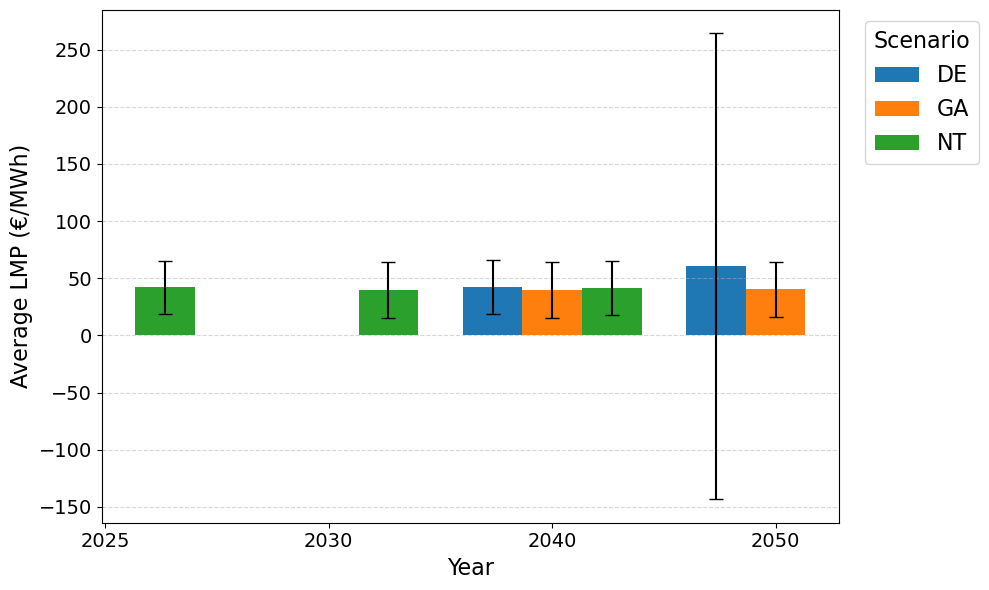

In [76]:
analytics.plot_annual_lmp_by_scenario(power_balance_duals, savefolder=dual_folder)

Average LMP by Year and Scenario


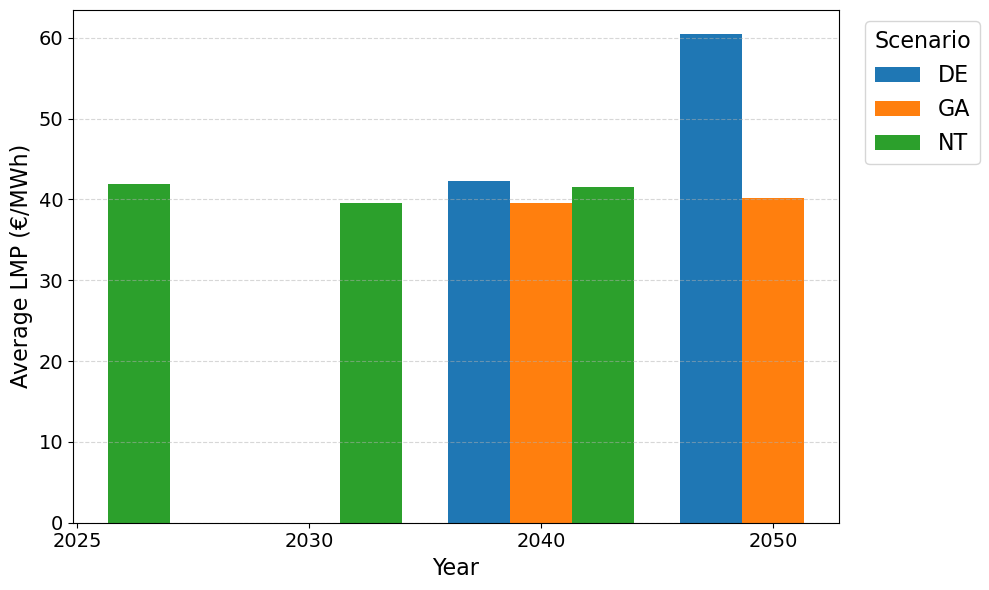

In [77]:
analytics.plot_annual_lmp_by_scenario_simple(
    power_balance_duals, savefolder=dual_folder
)

Average LMP by Year and Scenario (line chart)


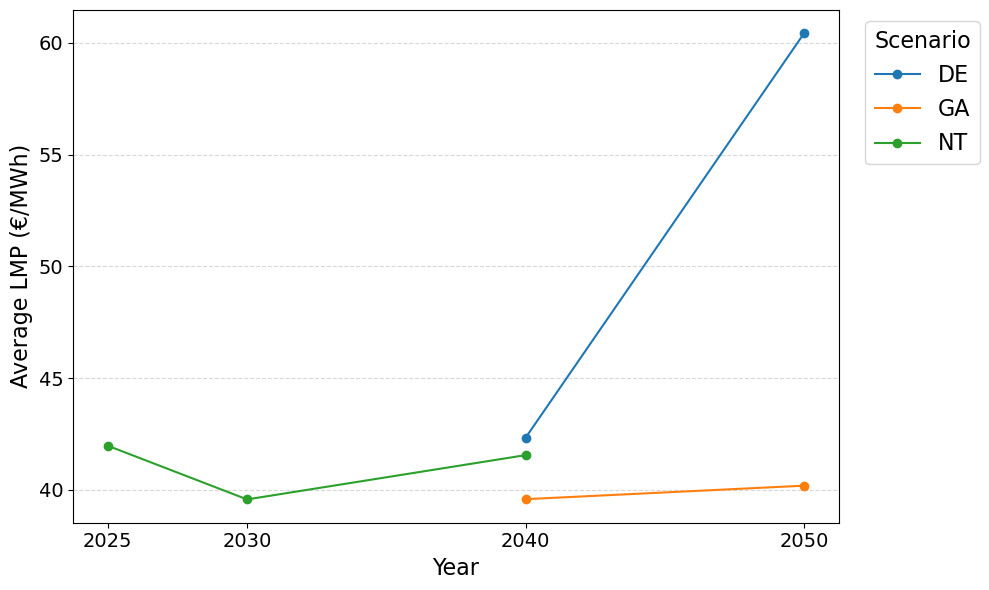

In [78]:
analytics.plot_annual_lmp_by_scenario_line(power_balance_duals, savefolder=dual_folder)

Annual Average Locational Marginal Prices by City (with markers)


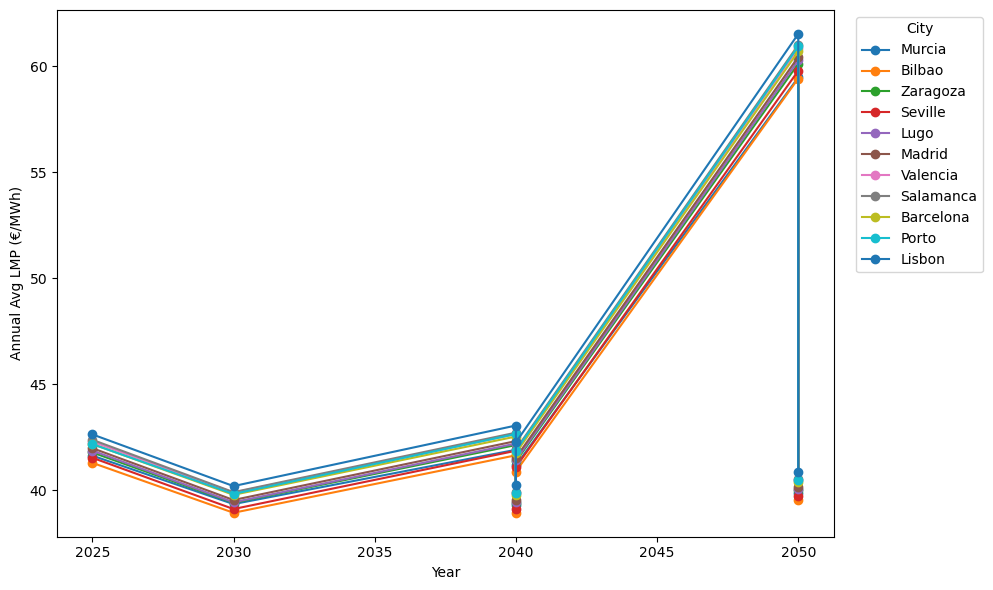

In [79]:
analytics.plot_nodal_price_evolution_with_markers(lmp_table, savefolder=dual_folder)

Annual Average Locational Marginal Prices by City (grouped bar)


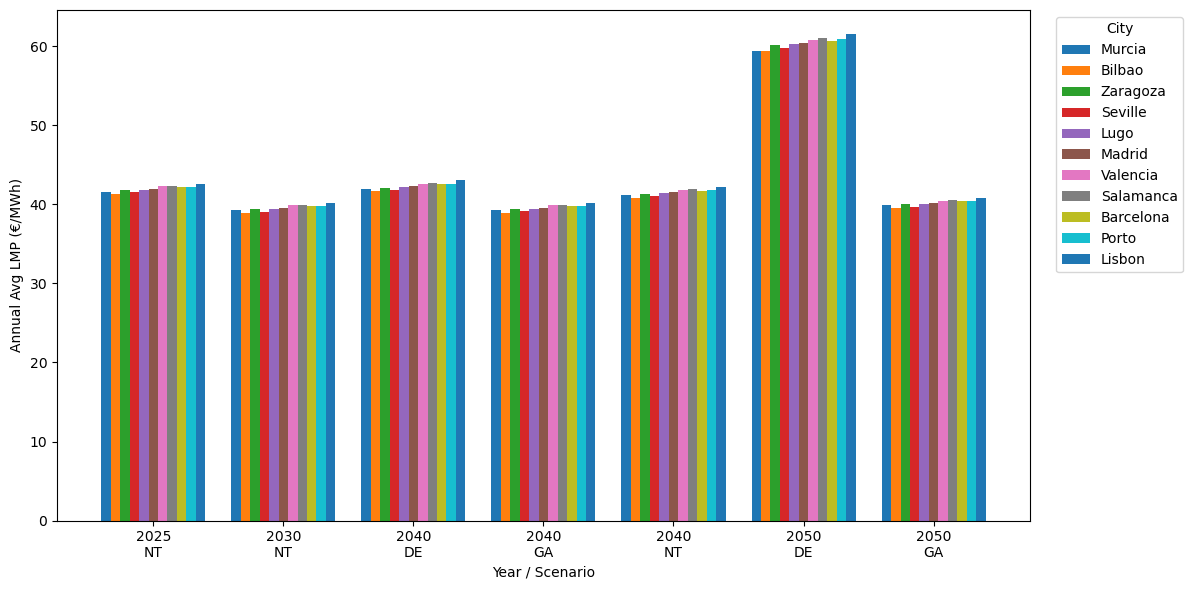

In [80]:
analytics.plot_nodal_price_grouped_bar(
    lmp_table, node_to_city=node_to_city, savefolder=dual_folder
)

In [81]:
branch_extension_duals = branch_extension_duals.rename_axis(index={"branch": "line"})
branch_extension_duals

dual_value
line year             
88   2025 -6019.777773
     2030     0.000000
     2040     0.000000
     2050     0.000000
89   2025     0.000000
...                ...
107  2050     0.000000
219  2025     0.000000
     2030     0.000000
     2040     0.000000
     2050     0.000000

[76 rows x 1 columns]

In [82]:
generators["production_cost"] = (
    generators["marginal_cost"] + generators["co2_emissions"] * CO2_price
)
generators.groupby("carrier")["production_cost"].mean().sort_values(ascending=True)

carrier
ror            0.000000
solar          0.010000
onwind         0.015000
offwind-ac     0.015000
coal          55.396970
CCGT          56.520397
Name: production_cost, dtype: float64

In [83]:
freqs = analytics.compute_lmp_bucket_frequencies(
    power_balance_duals, generators, dual_tables_folder
)


freqs

LMP Bucket Frequencies


,lower,upper,absolute,relative_percent
bucket,,,,
non-binding,-0.000100,0.000100,0,0.000000
gap_non-binding_solar,0.000100,0.009000,0,0.000000
solar,0.009000,0.011000,0,0.000000
gap_solar_wind,0.011000,0.013500,0,0.000000
wind,0.013500,0.016500,13062,25.243506
gap_wind_thermal,0.016500,49.857273,773,1.493893
thermal,49.857273,62.172437,37212,71.915584
other,NaN,NaN,697,1.347016


LMP Bucket Absolute Frequencies


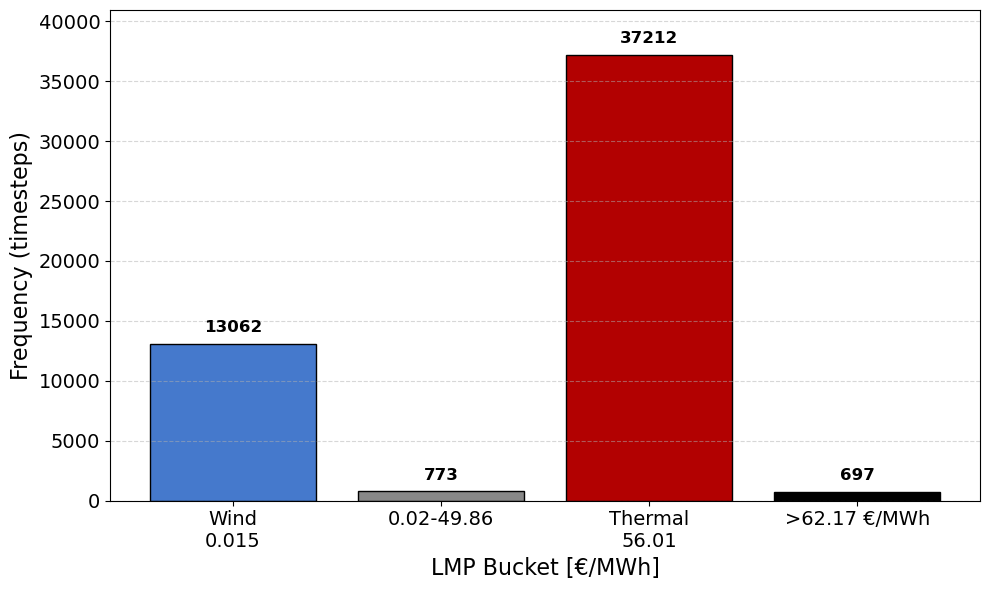

In [84]:
analytics.plot_lmp_bucket_frequencies(freqs, savefolder=dual_folder)

In [85]:
freqs

,lower,upper,absolute,relative_percent
bucket,,,,
non-binding,-0.000100,0.000100,0,0.000000
gap_non-binding_solar,0.000100,0.009000,0,0.000000
solar,0.009000,0.011000,0,0.000000
gap_solar_wind,0.011000,0.013500,0,0.000000
wind,0.013500,0.016500,13062,25.243506
gap_wind_thermal,0.016500,49.857273,773,1.493893
thermal,49.857273,62.172437,37212,71.915584
other,NaN,NaN,697,1.347016


LMP Bucket Relative Frequencies (%)


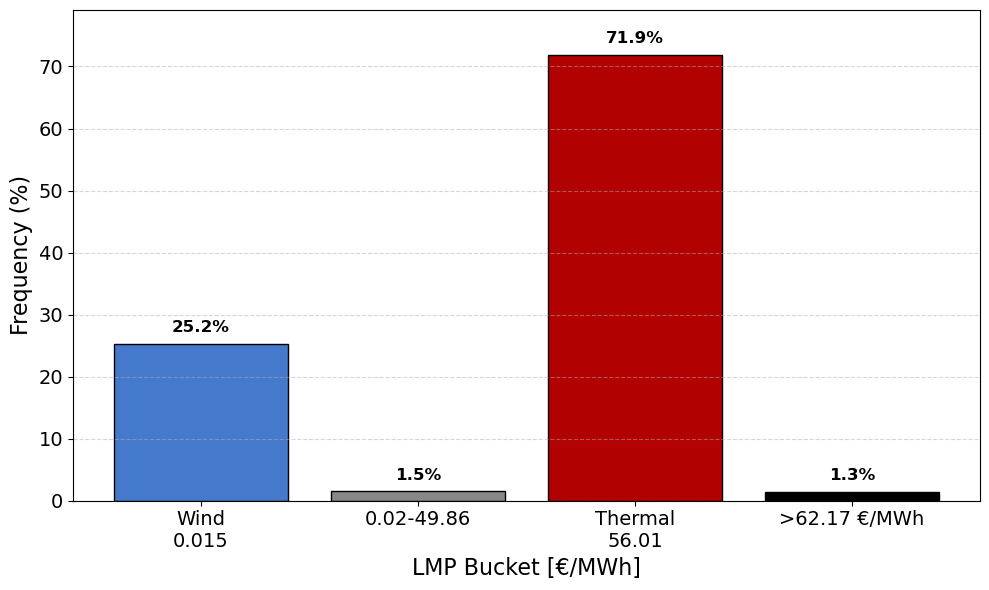

In [86]:
analytics.plot_lmp_bucket_percentages(freqs, savefolder=dual_folder)

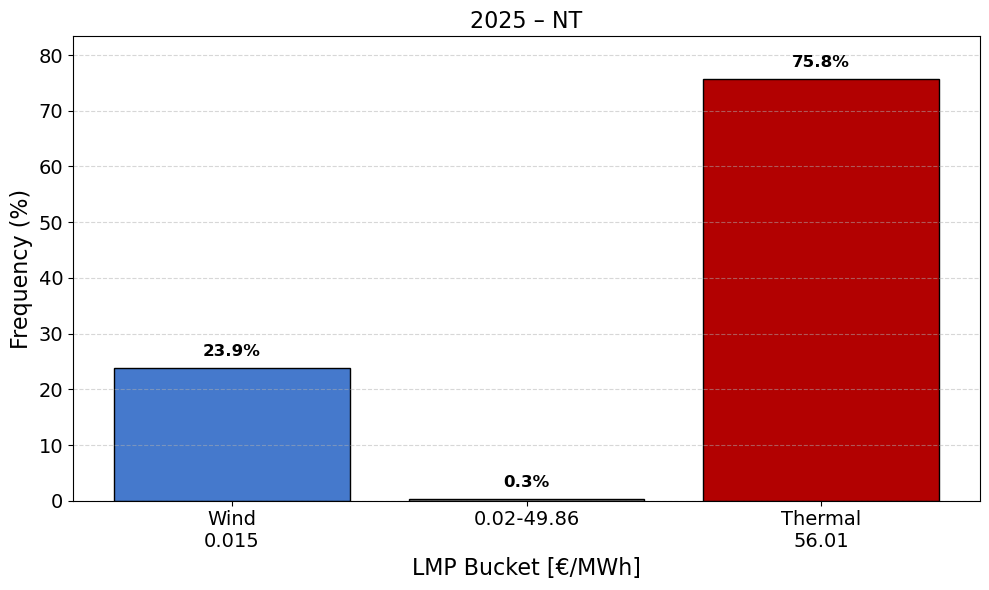

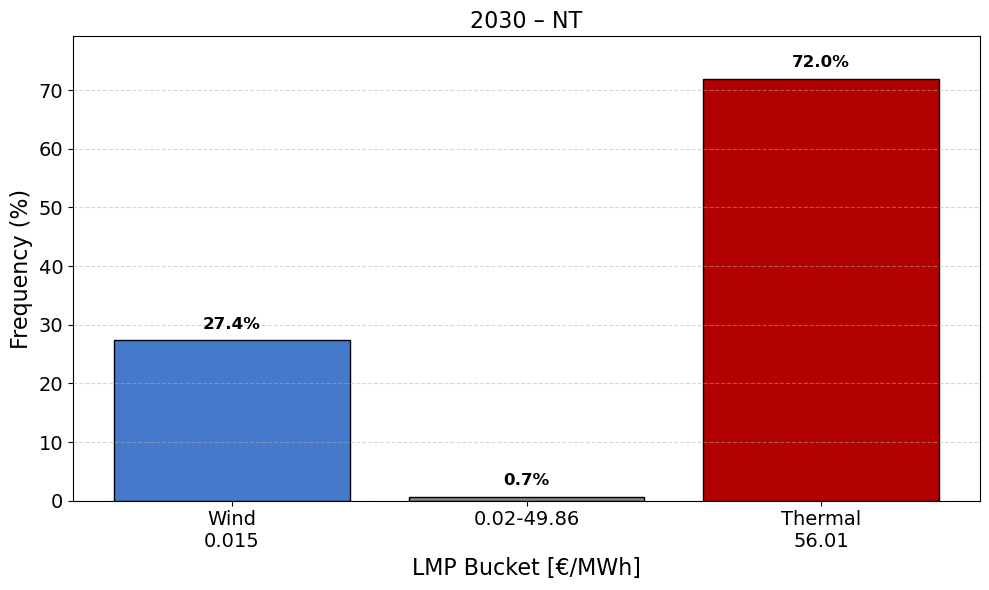

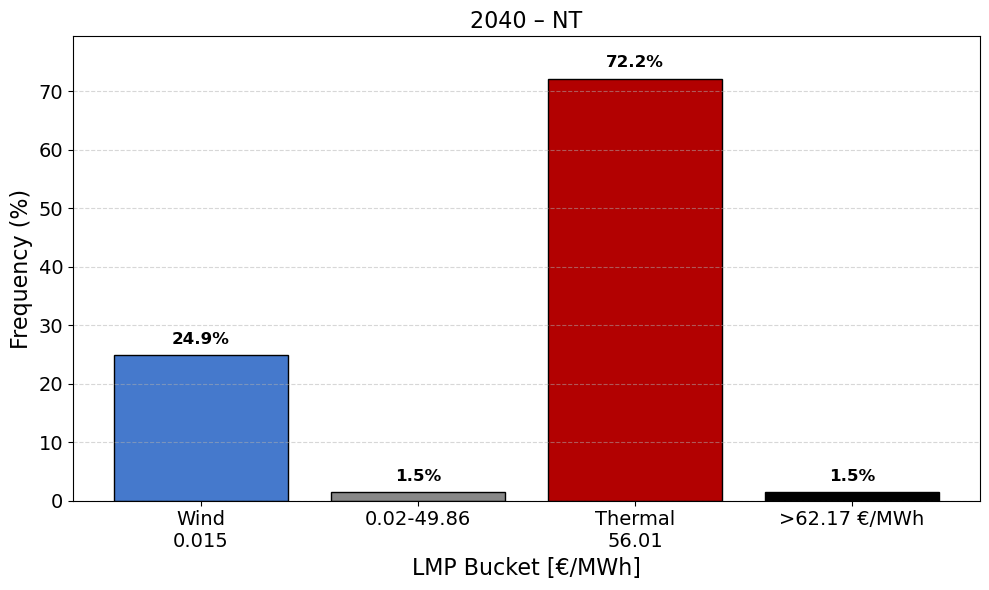

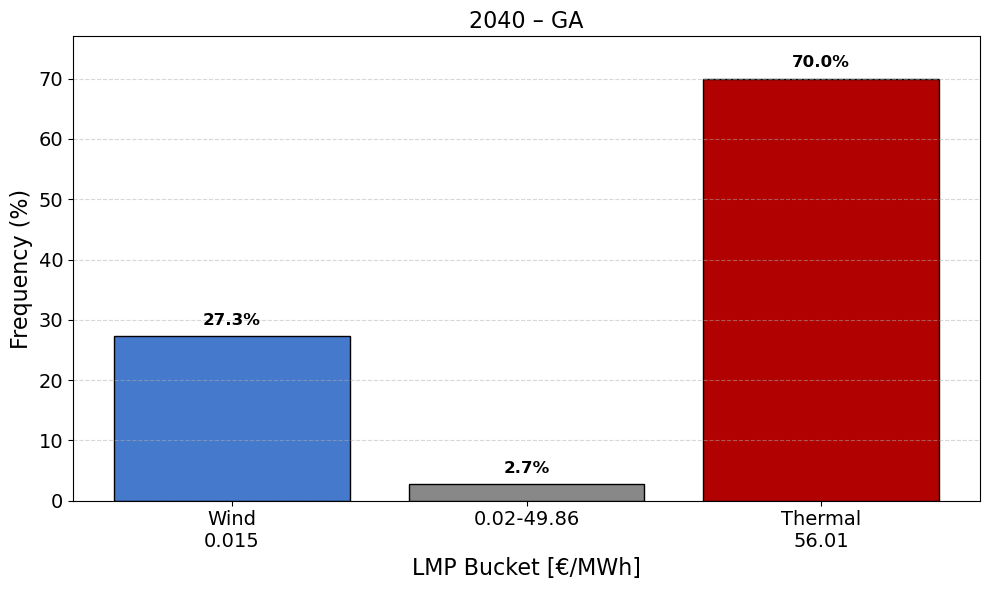

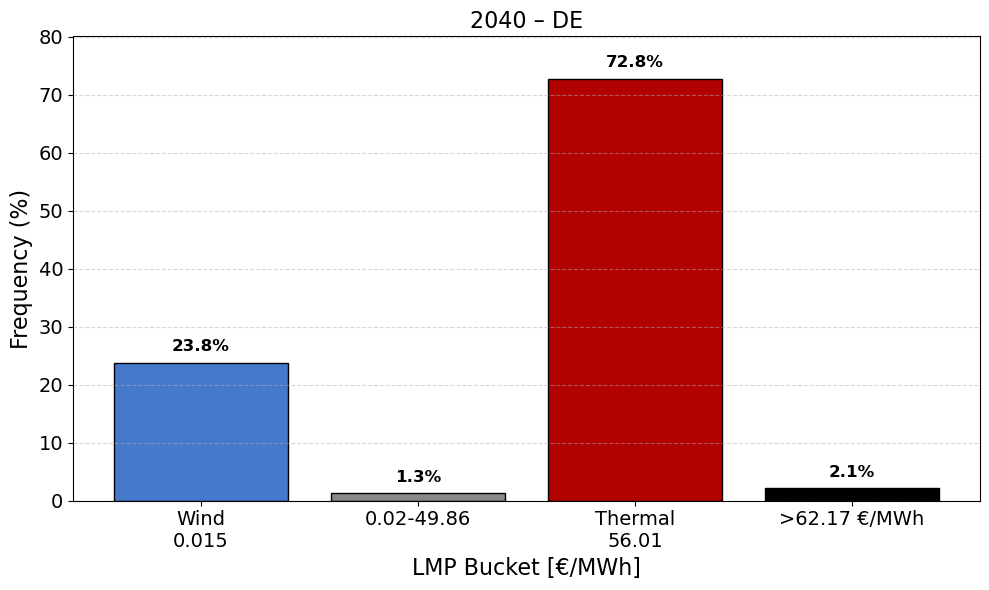

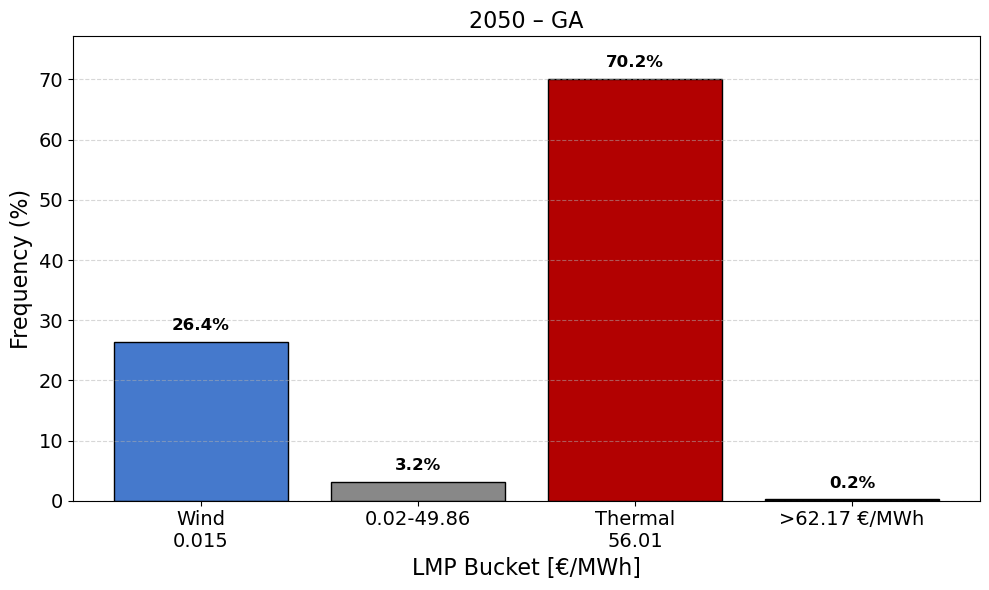

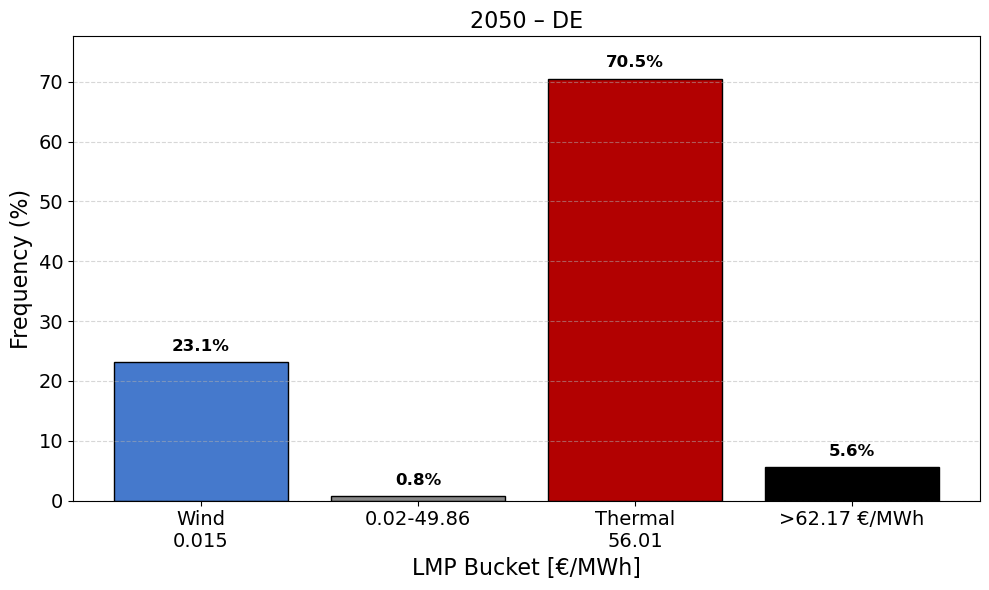

In [87]:
analytics.plot_lmp_bucket_percentages_by_year_scenario(
    power_balance_duals, freqs, savefolder=dual_folder
)

LMP event counts above 62.17 €/MWh by Year & Scenario


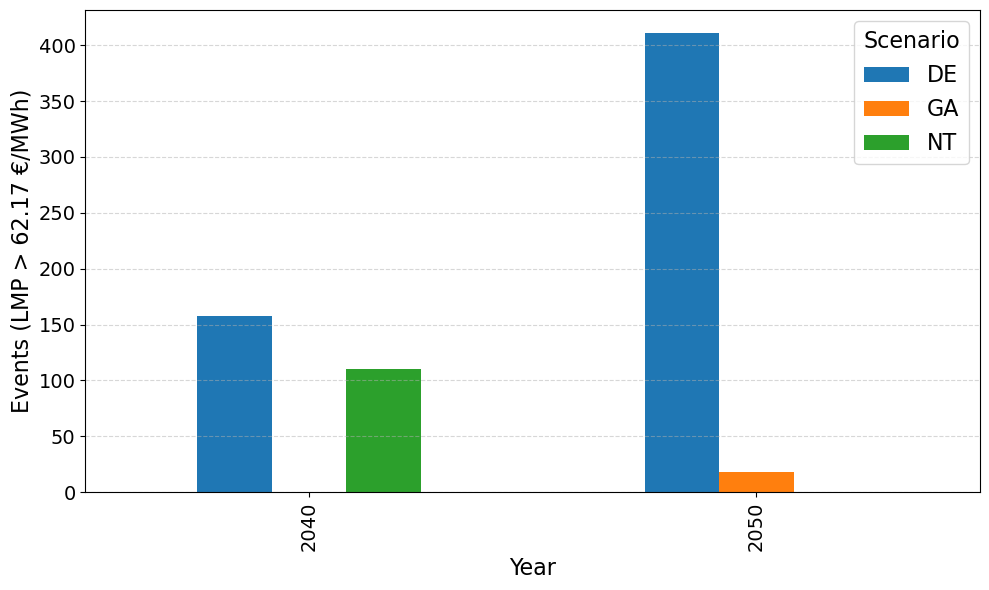

In [88]:
# determine cap from your buckets:
cap = freqs.loc[freqs.index != "other", "upper"].max()

analytics.plot_high_lmp_event_counts(power_balance_duals, cap, savefolder=dual_folder)

62.1724371519848
Distribution of LMPs > 62.17 €/MWh


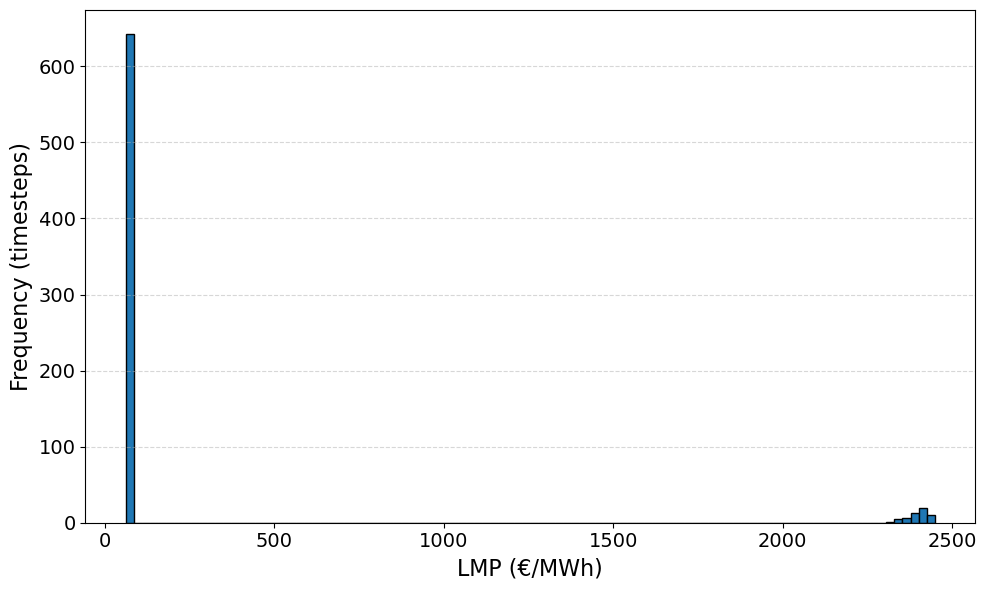

In [89]:
cap = freqs.loc[freqs.index != "other", "upper"].max()
print(cap)


analytics.plot_high_lmp_distribution(
    power_balance_duals, cap, n_bins=100, savefolder=dual_folder
)

    lower_bound  upper_bound  count  percent_of_high  percent_of_total
49     2409.540     2448.510     22        40.000000          0.042517
48     2370.570     2409.540     21        38.181818          0.040584
47     2331.599     2370.570     11        20.000000          0.021259
46     2292.629     2331.599      1         1.818182          0.001933
36     1902.927     1941.897      0         0.000000          0.000000
27     1552.195     1591.166      0         0.000000          0.000000
28     1591.166     1630.136      0         0.000000          0.000000
29     1630.136     1669.106      0         0.000000          0.000000
30     1669.106     1708.076      0         0.000000          0.000000
31     1708.076     1747.046      0         0.000000          0.000000
Top 5 high-LMP bins by occurrence


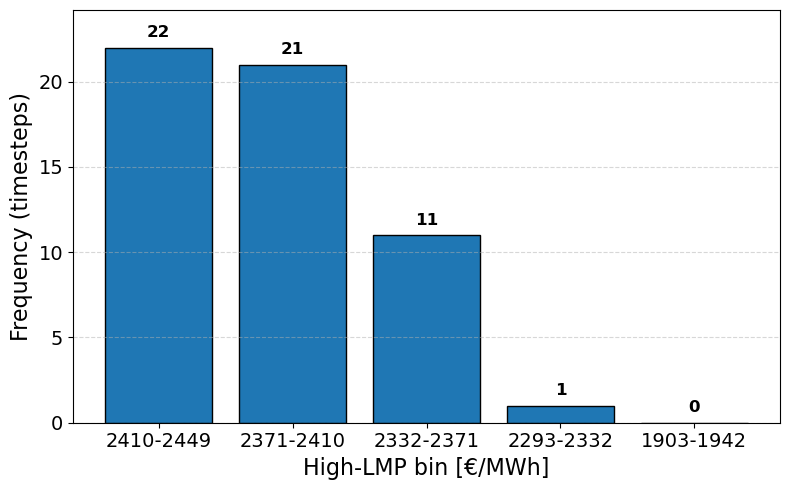

In [90]:
high_tbl = analytics.make_high_lmp_frequency_table(
    power_balance_duals, cap=500, n_bins=50, savefolder=dual_tables_folder
)
top5 = analytics.get_top_high_lmp_buckets(
    high_tbl, top_n=10, savefolder=dual_tables_folder
)
print(top5)
analytics.plot_top_high_lmp_buckets(high_tbl, top_n=5, savefolder=dual_folder)

    lower_bound  upper_bound  count  percent_of_high  percent_of_total
0        62.171       86.036    642        92.109039          1.240724
98     2400.783     2424.647     20         2.869440          0.038652
97     2376.920     2400.783     13         1.865136          0.025124
99     2424.647     2448.510     10         1.434720          0.019326
96     2353.057     2376.920      6         0.860832          0.011596
95     2329.193     2353.057      5         0.717360          0.009663
94     2305.330     2329.193      1         0.143472          0.001933
4       157.626      181.489      0         0.000000          0.000000
63     1565.565     1589.429      0         0.000000          0.000000
72     1780.336     1804.199      0         0.000000          0.000000
Top 6 high-LMP bins by occurrence


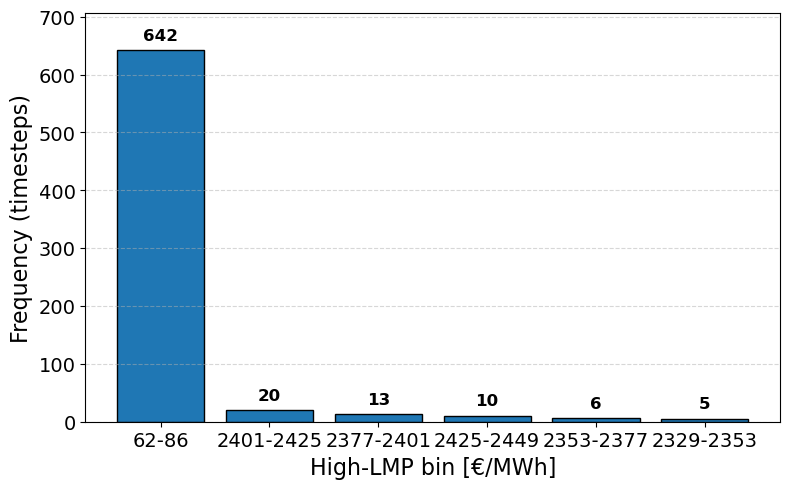

In [91]:
high_tbl = analytics.make_high_lmp_frequency_table(
    power_balance_duals, cap=cap, n_bins=100, savefolder=dual_tables_folder
)
top5 = analytics.get_top_high_lmp_buckets(
    high_tbl, top_n=10, savefolder=dual_tables_folder
)
print(top5)
analytics.plot_top_high_lmp_buckets(high_tbl, top_n=6, savefolder=dual_folder)

Detailed histogram for top high-LMP bucket (62.17–86.04 €/MWh)


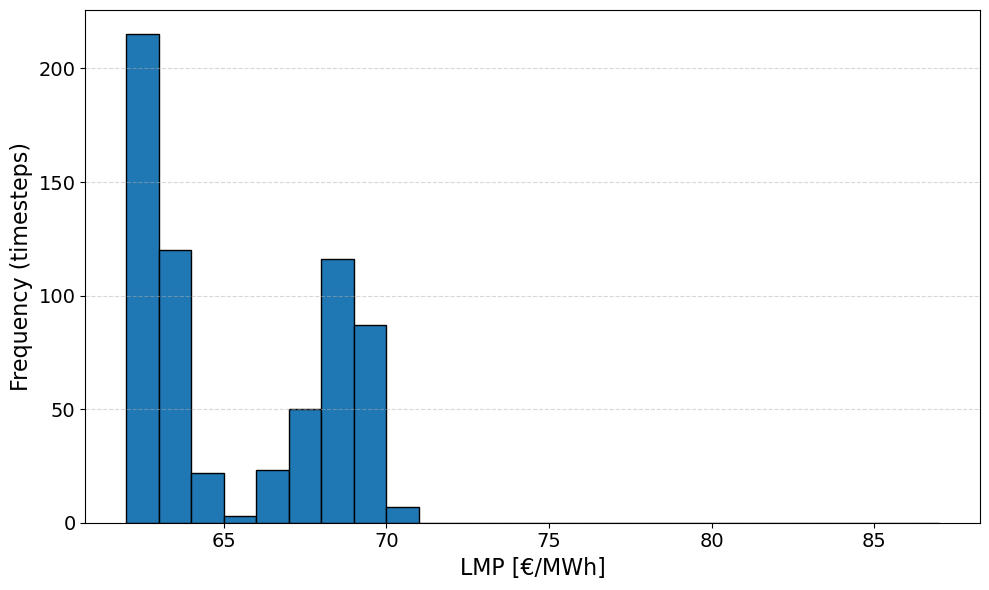

In [92]:
# Assuming you've already built `high_tbl`:
analytics.plot_top_high_bucket_detail(
    power_balance_duals, high_tbl, width=1.0, savefolder=dual_folder
)

In [93]:
power_balance_duals

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 11   0       0.014869  1.0     1.0
                         1       0.015050  1.0     1.0
                         2       0.015049  1.0     1.0
                         3       0.015049  1.0     1.0
                         4       0.015049  1.0     1.0
...                                   ...  ...     ...
PT1 1 DE       2050 52   163    56.522234  0.5     2.0
                         164    56.524591  0.5     2.0
                         165    56.526947  0.5     2.0
                         166    56.529304  0.5     2.0
                         167    56.360010  0.5     2.0

[51744 rows x 3 columns]

               count_total  count_bucket  percent_bucket_of_total
year scenario                                                    
2025 NT               7392            25                 0.338203
2030 NT               7392            50                 0.676407
2040 DE               7392            93                 1.258117
     GA               7392           200                 2.705628
     NT               7392           110                 1.488095
2050 DE               7392            59                 0.798160
     GA               7392           236                 3.192641
Distribution of LMPs in bucket 'gap_wind_thermal'


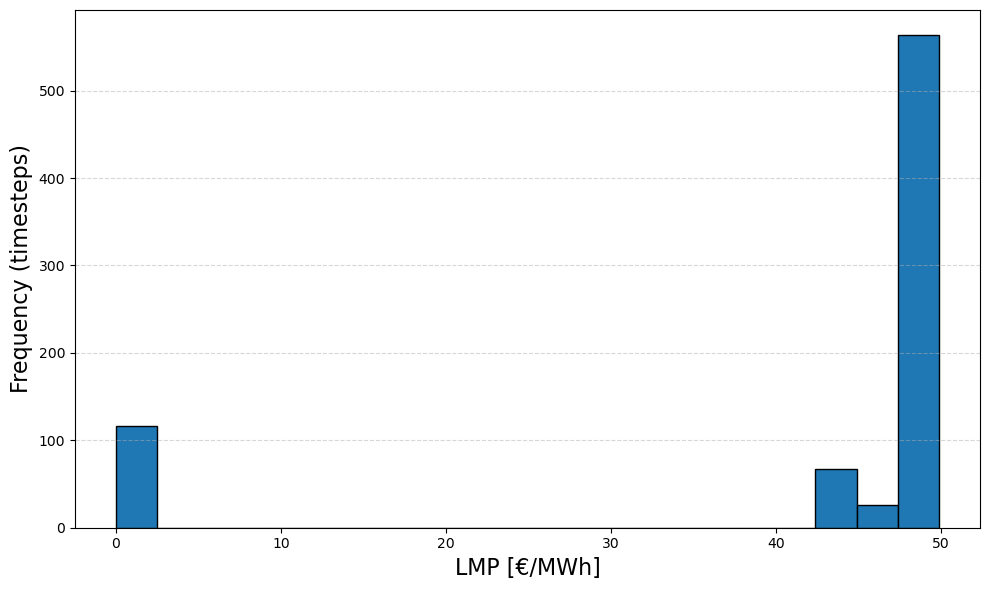

In [94]:
gap_subset = analytics.extract_duals_in_lmp_bucket(
    power_balance_duals, freqs, "gap_wind_thermal"
)
gap_summary = analytics.summarize_gap_duals_by_year_scenario(
    gap_subset, power_balance_duals, savefolder=dual_tables_folder
)
print(gap_summary)
analytics.plot_gap_lmp_distribution(
    gap_subset, "gap_wind_thermal", savefolder=dual_folder
)

LMP ≥ 70 €/MWh: count = 62 timesteps


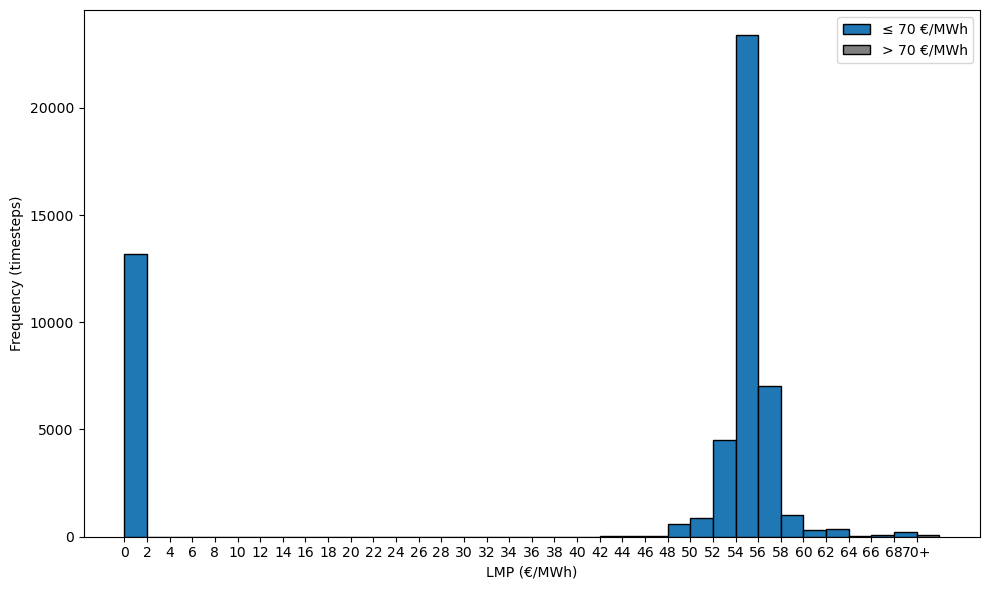

In [95]:
analytics.plot_lmp_histogram_70plus(
    power_balance_duals, cap=70, bin_width=2.0, savefolder=dual_folder
)

In [96]:
freq_table = analytics.make_lmp_frequency_table(
    power_balance_duals, bin_width=1.0, cap=70, savefolder=dual_tables_folder
)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    sorted_freq_table = freq_table.sort_values(by="count", ascending=False)
    display(sorted_freq_table)

,lower_bound,upper_bound,count,percent,count_2025,count_2030,count_2040,count_2050
54,54.0,55.0,13696,26.468769,2254,2220,5705,3517
0,0.0,1.0,13178,25.467687,1771,2057,5643,3707
55,55.0,56.0,9694,18.734539,1746,1291,4011,2646
56,56.0,57.0,4406,8.514997,779,495,1863,1269
53,53.0,54.0,4051,7.828927,365,803,1803,1080
57,57.0,58.0,2643,5.107839,312,220,1258,853
58,58.0,59.0,839,1.621444,71,56,441,271
50,50.0,51.0,540,1.043599,38,104,205,193
49,49.0,50.0,470,0.908318,18,21,212,219
52,52.0,53.0,436,0.842610,11,57,207,161


In [97]:
generators["production_cost"].groupby(generators["carrier"]).mean().sort_values(
    ascending=True
)

carrier
ror            0.000000
solar          0.010000
onwind         0.015000
offwind-ac     0.015000
coal          55.396970
CCGT          56.520397
Name: production_cost, dtype: float64

In [98]:
# plot_top_10_dual_intervals(
#     power_balance_duals, sorted_freq_table, n_bins=10, savefolder=dual_folder
# )
# create_top_10_dual_intervals_tables(
#     power_balance_duals, freq_table, n_bins=10, savefolder=dual_tables_folder
# )

In [99]:
average_duals = power_balance_duals.groupby("year")["dual_value"].mean()
average_duals

year
2025    41.972952
2030    39.572422
2040    41.155044
2050    50.305614
Name: dual_value, dtype: float64

In [100]:
summary_by_carrier = analytics.summarise_extension_status_by_carrier(
    generators, savefolder=generators_save_table_folder
)


summary_by_carrier

Extension status by carrier


extension_status  not extended  partly extended  fully extended
year carrier                                                   
2025 CCGT                    7                1               3
     coal                    5                0               0
     offwind-ac              1                1               7
     onwind                  0                0              11
     ror                     0                0               4
     solar                   0                0              11
2030 CCGT                   10                0               1
     coal                    5                0               0
     offwind-ac              4                0               5
     onwind                  2                0               9
     ror                     0                0               4
     solar                   0                0              11
2040 CCGT                   11                0               0
     coal                    5                0               0
     offwind-ac              7                0               2
     onwind                  6                0               5
     ror                     4                0               0
     solar                   0                0              11
2050 CCGT                   11                0               0
     coal                    5                0               0
     offwind-ac              9                0               0
     onwind                 10                0               1
     ror                     4                0               0
     solar                   0                0              11

In [101]:
# Usage example:
summary_table = analytics.summarize_dual_nonzero_counts(
    dual_variables, dual_tables_folder
)
summary_table

,total_duals,nonzero_duals,percent_nonzero
dual,,,
battery_charge_new_max_duals,51744,1541,2.978123
battery_charge_old_duals,0,0,0.000000
battery_discharge_new_max_duals,51744,419,0.809756
battery_discharge_old_duals,0,0,0.000000
branch_extension_duals,76,2,2.631579
branch_flow_new_duals_max,89376,12668,14.173827
branch_flow_new_duals_min,89376,32247,36.080156
branch_flow_old_duals_max,89376,12638,14.140261
branch_flow_old_duals_min,89376,32228,36.058897


In [102]:
summary = analytics.summarize_duals_by_year_scenario(
    dual_variables, savefolder=dual_tables_folder
)

with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.width", None
):

    display(summary)

total_duals  nonzero_duals  \
dual                            year scenario                               
battery_charge_new_max_duals    2025 NT               7392            177   
                                2030 NT               7392            283   
                                2040 DE               7392            130   
                                     GA               7392            282   
                                     NT               7392            134   
                                2050 DE               7392            309   
                                     GA               7392            226   
battery_discharge_new_max_duals 2025 NT               7392             56   
                                2030 NT               7392             65   
                                2040 DE               7392             55   
                                     GA               7392             48   
                                     NT               7392             56   
                                2050 DE               7392             70   
                                     GA               7392             69   
branch_extension_duals          2025 All                19              2   
                                2030 All                19              0   
                                2040 All                19              0   
                                2050 All                19              0   
branch_flow_new_duals_max       2025 NT              12768           1776   
                                2030 NT              12768           1677   
                                2040 DE              12768           1860   
                                     GA              12768           1753   
                                     NT              12768           1846   
                                2050 DE              12768           1941   
                                     GA              12768           1815   
branch_flow_new_duals_min       2025 NT              12768           4667   
                                2030 NT              12768           4699   
                                2040 DE              12768           4577   
                                     GA              12768           4614   
                                     NT              12768           4566   
                                2050 DE              12768           4528   
                                     GA              12768           4596   
branch_flow_old_duals_max       2025 NT              12768           1769   
                                2030 NT              12768           1672   
                                2040 DE              12768           1855   
                                     GA              12768           1752   
                                     NT              12768           1843   
                                2050 DE              12768           1937   
                                     GA              12768           1810   
branch_flow_old_duals_min       2025 NT              12768           4660   
                                2030 NT              12768           4698   
                                2040 DE              12768           4578   
                                     GA              12768           4613   
                                     NT              12768           4564   
                                2050 DE              12768           4519   
                                     GA              12768           4596   
emissions_duals                 2025 NT                  1              0   
                                2030 NT                  1              0   
                                2040 DE                  1              0   
                                     GA                  1              0   
                                     NT    

In [103]:
nz = analytics.list_nonzero_gen_extension_duals(
    gen_extension_duals, savefolder=dual_tables_folder
)

nz

dual_value
year generator                      
2025 ES1 4 offwind-ac -414622.990408
     ES1 4 onwind     -300239.303934
     PT1 1 ror        -282184.173627
     PT1 0 ror        -276454.628365
     ES1 2 onwind     -261751.235540
...                              ...
2050 ES1 7 solar       -24831.176177
     PT1 0 solar       -18268.389202
     ES1 4 solar       -13187.767979
     ES1 1 solar       -12443.985694
     ES1 4 onwind       -8674.939094

[96 rows x 1 columns]

In [104]:
generators.groupby("carrier")["capital_cost"].mean()

carrier
CCGT           98952.729293
coal          349901.553630
offwind-ac    184121.306769
onwind         96010.888020
ror           299065.224929
solar          35527.071244
Name: capital_cost, dtype: float64